<div style="background-color: #e0f7fa; color: #000000; padding: 15px; border-radius: 5px;">
    <div style="font-size: 22px; font-weight: bold;">
        Water Potability Exploratory Data Analysis (EDA)/ Data Visualization
    </div>
    <div style="font-size: 14px; margin-top: 5px;">
        Author: Shamim Noroozi
    </div>
</div>

<div style="background-color: #e0f7fa; color: #000000; padding: 7px 7px 0 7px; border-radius: 5px;">
    <div style= "font-size: 20px; font-weight: bold; margin-bottom: 13px;">
        About Dataset:
    </div>
    <div style= "font-size: 16px; margin-bottom: 12px;">
        The Water Quality Dataset from Kaggle contains measurements of water-quality characteristics that can be used to examine patterns and relationships among different physicochemical parameters. In this notebook, I performed Exploratory Data Analysis (EDA), an important step in the data analysis and data science workflow, to understand the dataset before further modeling. The analysis includes assessing data quality, identifying and handling missing values, examining distributions and potential outliers, and creating visualizations to explore relationships, correlations, and patterns among the variables.
    </div>
    <div style= "font-size: 16px; margin-bottom: 10px;">
        This dataset includes 3276 samples from different water supplies and 10 columns that each indicates different parameters of water. 
    </div>
    <div style= "font-size: 16px; margin-bottom: 10px;">
        - PH: Is an important paremeters that evaluates whether water is acidic or alkaline. The common reference range for drinking water is 6.5 to 8.5.
    </div>
    <div style= "font-size: 16px; margin-bottom: 10px;">
        - Hardness: Measures the amount of dissolved calcium and magnesium. Water with 60 to 120 mg/L as CaCO₃ is moderately hard. Water with 120 to 180 mg/L is hard.
    </div>
    <div style= "font-size: 16px; margin-bottom: 10px;">
        - Solids: Represents the total dissolved minerals, salts, and metals in water. A value below 500 mg/L is often preferred for acceptable taste.
    </div>
    <div style= "font-size: 16px; margin-bottom: 10px;">
        - Solids: Represents the total dissolved minerals, salts, and metals in water. A value below 500 mg/L is often preferred for acceptable taste with the maximum value at 1000 mg/L.
    </div>
    <div style= "font-size: 16px; margin-bottom: 10px;">
        - Chloramines: Measures chloramine disinfectants in water. A value below 4 mg in 4 mg/L or 4 ppm is often preferred for drinkable water.
    </div>
    <div style= "font-size: 16px; margin-bottom: 10px;">
        - Sulfate: Measures the amount of dissolved sulfate in water.It ranges from 3 to 30 mg/L in most freshwater supplies, although much higher concentrations (1000 mg/L) are found in some geographic locations.
    </div>
    <div style= "font-size: 16px; margin-bottom: 10px;">
        - Conductivity: Measures how well water conducts electricity. It reflects the amount of dissolved ions in the water. According to WHO standards, EC value should not exceeded 400 μS/cm.
    </div>
    <div style= "font-size: 16px; margin-bottom: 10px;">
        - Organic_carbon: Measures the amount of carbon found in organic compounds in water. It can affect water treatment and the formation of disinfection byproducts. According to US EPA < 2 mg/L as TOC in treated / drinking water, and < 4 mg/Lit in source water which is use for treatment.
    </div>
    <div style= "font-size: 16px; margin-bottom: 10px;">
        - Trihalomethanes: Measures disinfection byproducts that can form when chlorine reacts with organic matter. THM levels up to 80 ppm is considered safe in drinking water.
    </div>
    <div style= "font-size: 16px; margin-bottom: 10px;">
        - Turbidity: Measures the cloudiness of water. The WHO recommended value for turbidity is 5.00 NTU.
    </div>
    <div style= "font-size: 16px; margin-bottom: 12px;">
        - TPotability: Shows whether the water is considered safe to drink. A value of 0 means not potable. A value of 1 means potable.
    </div>
</div>

<div style= "background-color: #e0f7fa; color: #000000; padding: 15px; border-radius: 5px;">
    <div style= "font-size: 18px; margin-bottom: 12px; font-weight: bold;">
        The Aim of This Analysis 
    </div>
    <div style= "font-size: 16px; margin-bottom: 12px;">
        - Explore the dataset and examine the amount, distribution, and patterns of missing values.
    </div>
    <div style= "font-size: 16px; margin-bottom: 12px;">
        - Handle missing values using an appropriate imputation approach.
    </div>
    <div style= "font-size: 16px; margin-bottom: 12px;">
        - Visualize the data to examine feature distributions, relationships, correlations, and potential patterns among the variables.
    </div>
    <div style= "font-size: 16px; margin-bottom: 12px;">
        <b>Note:</b> The purpose of this notebook is exploratory data analysis and data preprocessing, not the development or evaluation of a predictive machine-learning model. Therefore, a train-test split was not performed before standardization and KNN imputation. If predictive modeling were performed, the data would first be divided into training and test sets, and preprocessing steps such as scaling and imputation would be fitted using the training data only to prevent data leakage.
    </div>
</div>

In [1]:
# Import the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
# Import data
# First make sure about the CSV delimiter
import csv
with open (r"G:\ML_IMT_Practices\Season 3\Project_1\water_potability.csv", "r") as f:
    delicate= csv.Sniffer().sniff(f.read(2000))
print(delicate.delimiter)    

,


In [3]:
# Load the data and convert it to a DataFrame
data= pd.read_csv(r"G:\ML_IMT_Practices\Season 3\Project_1\water_potability.csv")
df= pd.DataFrame(data)
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [4]:
class color:
    dark_green = "\033[32m"
    bold = "\033[1m"
    underline = "\033[4m"
    end = "\033[0m"

In [5]:
rows, col= df.shape
print(color.dark_green + color.bold + "Number of rows (samples)" + color.end)
print(rows)
print(color.dark_green + color.bold + "Number of columns" + color.end)
print(col)

Number of rows (samples)
3276
Number of columns
10


In [6]:
# List of columnns
print(color.dark_green + color.bold + "The list of columns" + color.end)
print(df.columns.tolist())

The list of columns
['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']


In [7]:
# Display a summary of the dataset
print(color.dark_green + color.bold + "Dataset Information" + color.end)
df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


The information indicates that all features are numerical with either float or int type, and there are some missing values in "PH", "Sulfate", and "Trihalmothanes" columns

In [8]:
# Display descriptive statistics for all features in the dataset
print(color.dark_green + color.bold + "Descriptive Statistics for Each Feature" + color.end)
print(df.describe(include= "all"))

Descriptive Statistics for Each Feature
                ph     Hardness        Solids  Chloramines      Sulfate  \
count  2785.000000  3276.000000   3276.000000  3276.000000  2495.000000   
mean      7.080795   196.369496  22014.092526     7.122277   333.775777   
std       1.594320    32.879761   8768.570828     1.583085    41.416840   
min       0.000000    47.432000    320.942611     0.352000   129.000000   
25%       6.093092   176.850538  15666.690297     6.127421   307.699498   
50%       7.036752   196.967627  20927.833607     7.130299   333.073546   
75%       8.062066   216.667456  27332.762127     8.114887   359.950170   
max      14.000000   323.124000  61227.196008    13.127000   481.030642   

       Conductivity  Organic_carbon  Trihalomethanes    Turbidity   Potability  
count   3276.000000     3276.000000      3114.000000  3276.000000  3276.000000  
mean     426.205111       14.284970        66.396293     3.966786     0.390110  
std       80.824064        3.308162      

In [9]:
# Calculate the percentage of missing values for each feature in the dataset
percentage_missing= []
features= []

for item in df.columns:
    features.append(item)
    percentage_missing.append((df[item].isna().sum())/(df.shape[0])*100)

percentage_missing_results= pd.DataFrame({
    'Features': features,
    'Percentage Missing': percentage_missing
}                                      
)

percentage_missing_results

,Features,Percentage Missing
0,ph,14.987790
1,Hardness,0.000000
2,Solids,0.000000
3,Chloramines,0.000000
4,Sulfate,23.840049
5,Conductivity,0.000000
6,Organic_carbon,0.000000
7,Trihalomethanes,4.945055
8,Turbidity,0.000000
9,Potability,0.000000


In [10]:
# Check for duplicate observations in the dataset
duplicate_rows = df[df.duplicated(keep=False)]
print(color.dark_green + color.bold + "Number of duplicate observations:" + color.end)
print(duplicate_rows.shape[0])

Number of duplicate observations:
0


### Missing Values Analysis

Missing values are common in real-world datasets and can occur for different reasons, such as **sensor or measurement failure, data transmission interruptions, incomplete user entries, unavailable measurements, or errors during data collection and storage**. Identifying both the **amount and pattern** of missingness is an important part of data preprocessing because untreated missing values can prevent some statistical and machine-learning methods from running, reduce the usable sample size if incomplete observations are simply removed, and potentially bias the analysis when the missingness is related to the variables being studied.

The table above shows that missing values are present in only three features of this dataset. **Sulfate** has the highest proportion of missing observations at approximately 23.84%, followed by **pH** at approximately 14.99%, and **Trihalomethanes** at approximately 4.95%. The remaining features, including the target variable Potability, contain no missing values. This indicates that missingness is concentrated in a limited subset of the water-quality measurements rather than being distributed across all features.

In addition to investigation of missing value percentages across the dataset, examining whether missing values occur in the same observations, how many features are missing per observation, and whether the missingness appears to be associated with other variables are alos important. 

To check the overlap between missing values across Sulfate, ph, and Trihalomethanes I used the **UpSet plot**.

### Figure 1: Visualization of the missing value overlap across the three columns "PH", "Sulfate" and "Trihalomethanes"

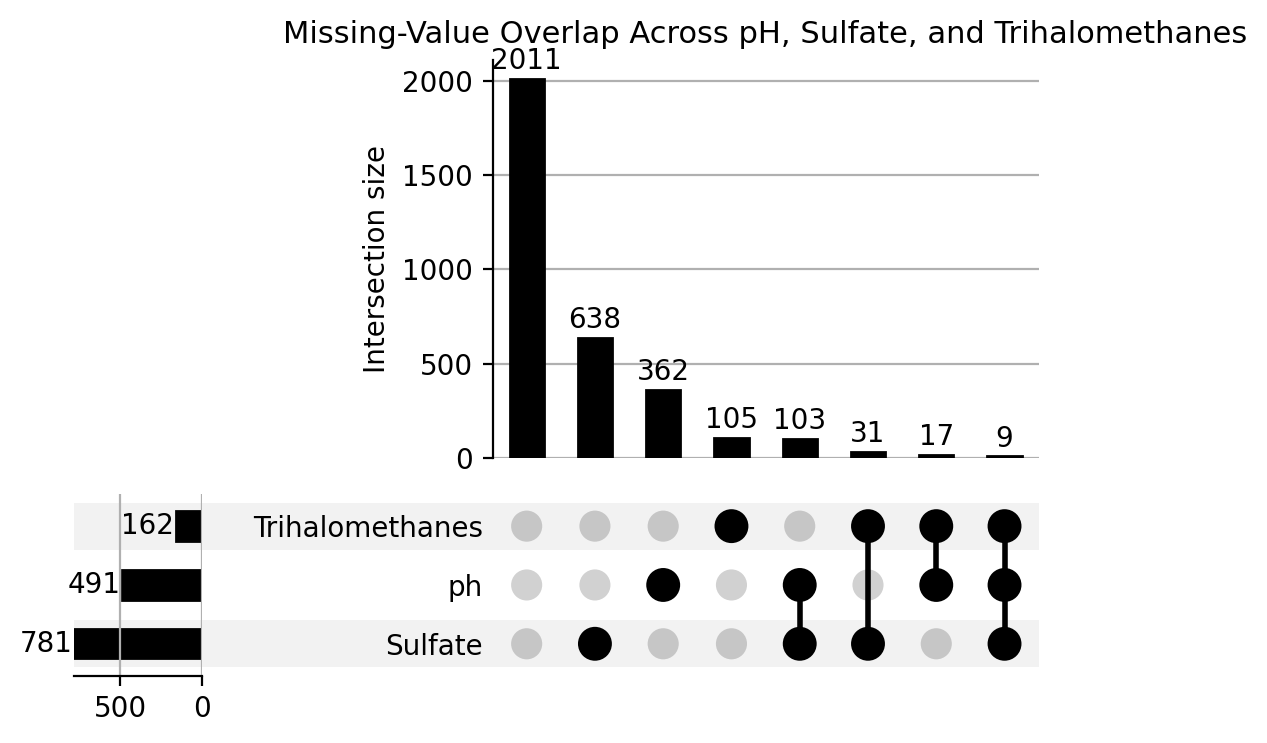

In [11]:
from upsetplot import from_indicators, plot

warnings.filterwarnings("ignore", category=FutureWarning, module="upsetplot")

plot(from_indicators(indicators=pd.isna, data=df), show_counts=True, fig=plt.figure(figsize=(8, 14), dpi=200));
plt.title("Missing-Value Overlap Across pH, Sulfate, and Trihalomethanes", fontsize= 11, color='black')
plt.show()

### The Upsetplot indicates that:
- 2,011 of 3,276 samples (61.39%) are complete across pH, Sulfate, and Trihalomethanes.
- 638 samples (19.47%) are missing only Sulfate.
- 362 samples (11.05%) are missing only pH.
- 105 samples (3.21%) are missing only Trihalomethanes.
- Missingness in two features simultaneously is much less common: 103 samples are missing both pH and Sulfate, 31 are missing Sulfate and Trihalomethanes, and 17 are missing pH and Trihalomethanes.
- Only 9 samples (0.27%) are missing all three variables.

### Finding the rows (samples) that have missing values for across all three features (ph, Sulfate, and Trihalomethanes)

In [12]:
df_missing_all= df[df[["ph", "Sulfate", "Trihalomethanes"]].isna().all(axis=1)].index
all_missing_percentage= (len(df_missing_all)/df.shape[0])*100

# Verify that the expected number of observations was identified

if len(df_missing_all)== 9:
    print(color.dark_green+ color.bold+ "Number of samples missing pH, Sulfate, and Trihalomethanes:"+ color.end)
    print(len(df_missing_all))
    print(color.dark_green + color.bold + "The initial sample size of the dataset was :"+ color.end)
    print(df.shape[0])
    pass
else:
    raise ValueError("The number of samples missing all three features does not match the expected value.")

Number of samples missing pH, Sulfate, and Trihalomethanes:
9
The initial sample size of the dataset was :
3276


In [13]:
# Remove observations with missing values across all three incomplete features
df_filtered= df.drop(index= df_missing_all)
df_filtered

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


### Visualization of the missing values distribution across the three columns "PH", "Sulfate" and "Trihalomethanes" with respect to "Potability"

In [14]:
df_filtered["Potability"]= np.where(df_filtered["Potability"]==0, "Not Potable", "Potable")
df_filtered["Potability"].value_counts()

Potability
Not Potable    1990
Potable        1277
Name: count, dtype: int64

In [15]:
# Adding "Missing" and "Not Missing" labels for ph, Sulfate, and Trihalomethanes for visulization
df_filtered["missing_ph"]= np.where(df_filtered["ph"].isna(), "Missing", "Not Missing")
df_filtered["missing_sulfate"]= np.where(df_filtered["Sulfate"].isna(), "Missing", "Not Missing")
df_filtered["missing_Trihalomethanes"]= np.where(df_filtered["Trihalomethanes"].isna(), "Missing","Not Missing")

missing_ph_vs_potability= df_filtered.groupby(["missing_ph","Potability"]).size().unstack()
missing_sulfate_vs_potability= df_filtered.groupby(["missing_sulfate","Potability"]).size().unstack()
missing_Trihalomethanes= df_filtered.groupby(["missing_Trihalomethanes","Potability"]).size().unstack()

In [16]:
font_dic= {"family": "Times New Roman", 'color': 'black', 'size': 20}

### Figue 2: Stacked-bar plot

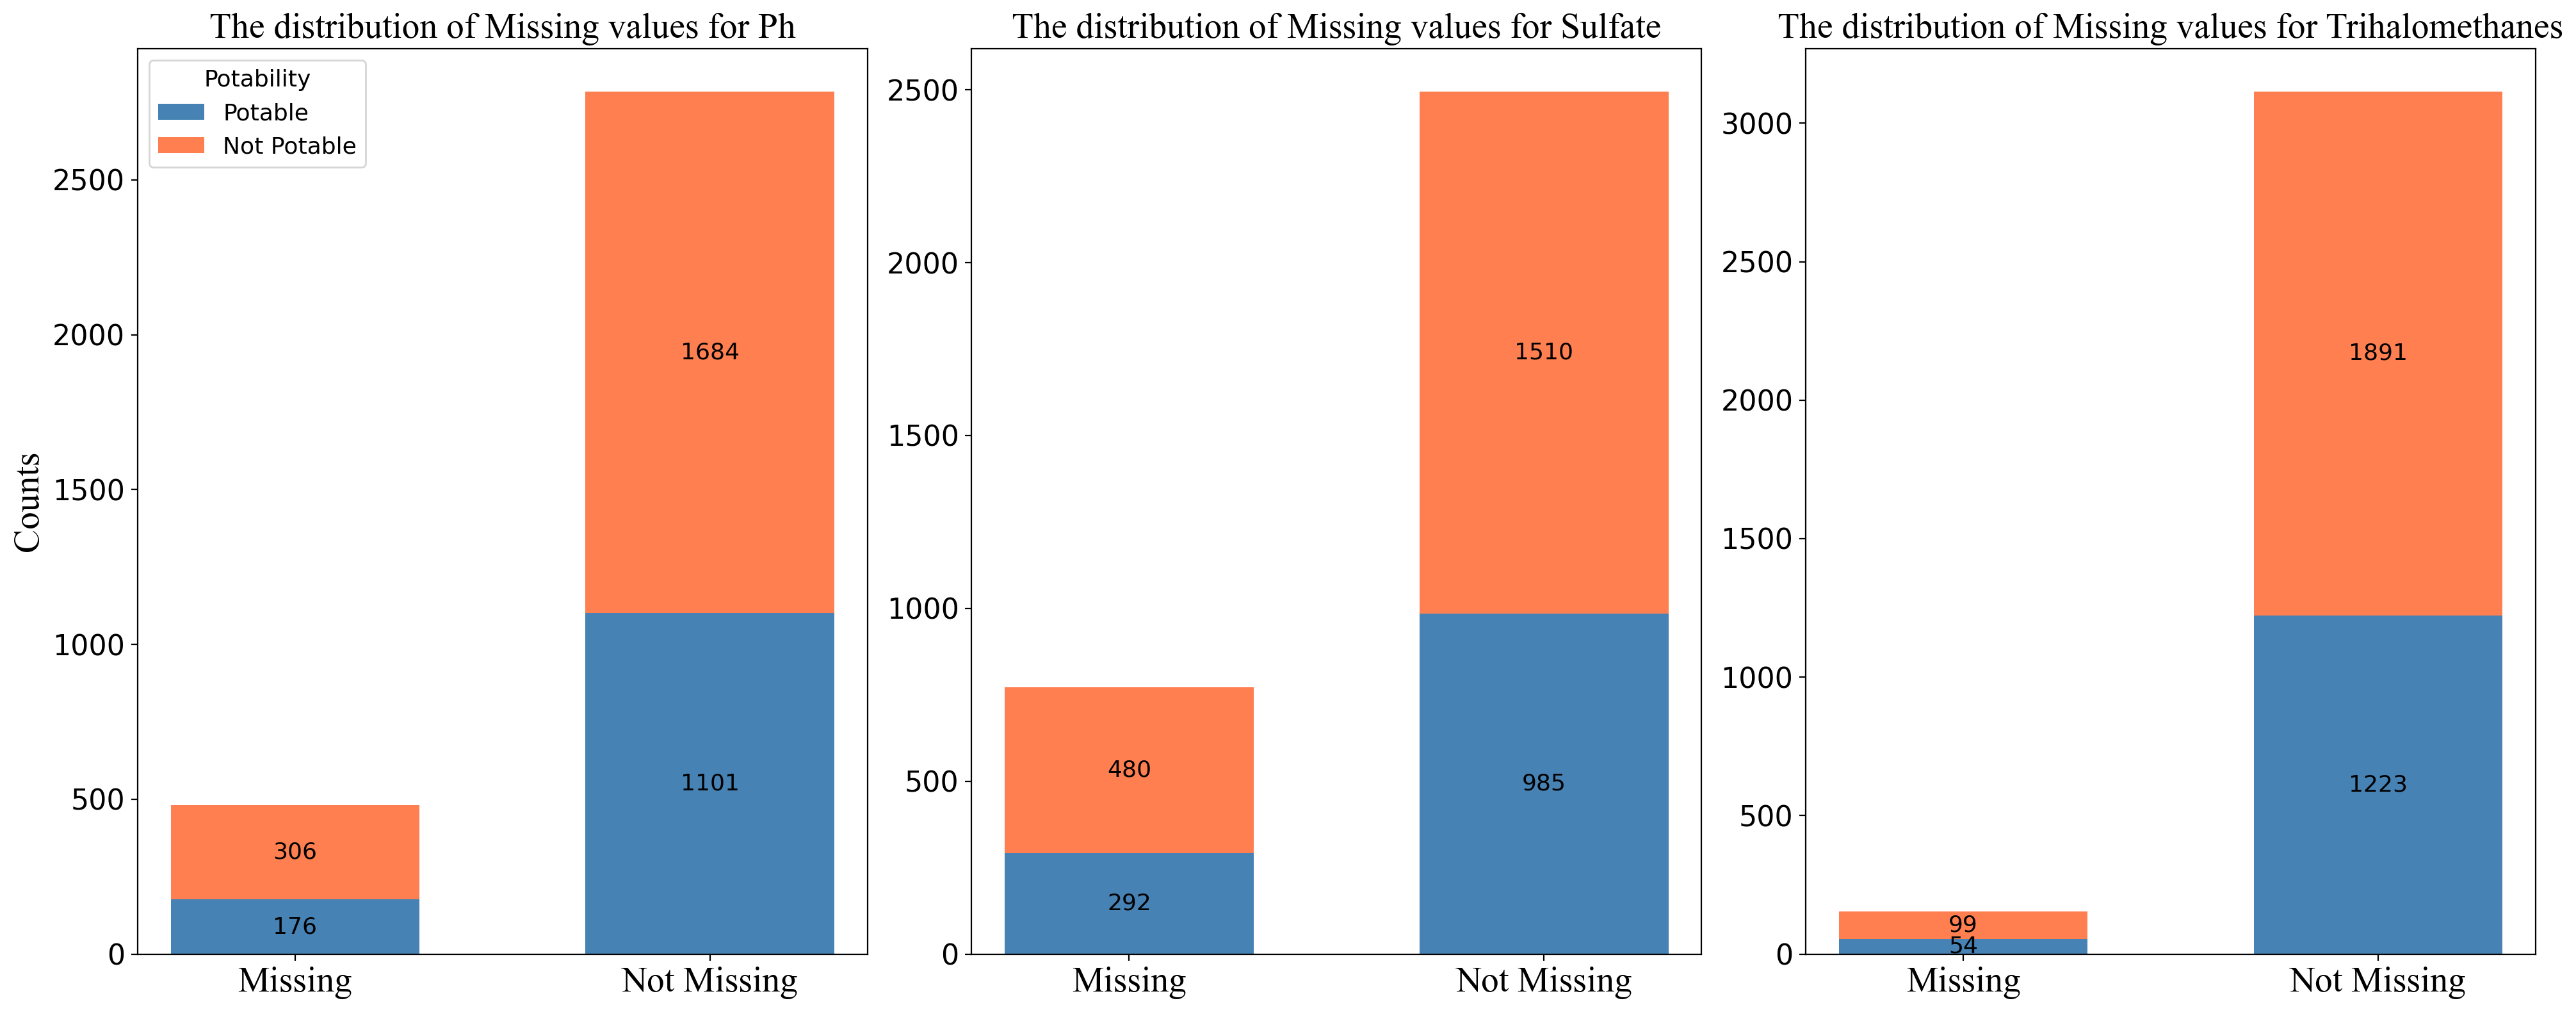

In [17]:
missing_categories = ("Missing", "Not Missing")
color_map={"Not Potable": "coral", "Potable": "steelblue"}
fig, axes= plt.subplots(1,3,figsize= (20,8), dpi= 200)
Features= ["Ph", "Sulfate", "Trihalomethanes"]
for ax , feature in zip(axes,Features):

    if feature== "Ph":
        table = missing_ph_vs_potability.reindex(missing_categories)
        potability_counts = {
        'Potable': table["Potable"].values,
        'Not Potable': table["Not Potable"].values}

    elif feature== "Sulfate":
        table = missing_sulfate_vs_potability.reindex(missing_categories)
        potability_counts = {
                'Potable': table["Potable"].values,
                'Not Potable': table["Not Potable"].values}
    else:
        table = missing_Trihalomethanes.reindex(missing_categories)
        potability_counts = {
                        'Potable': table["Potable"].values,
                        'Not Potable': table["Not Potable"].values}

    width = 0.6  
    bottom = np.zeros(2)

    for potability, potability_count in potability_counts.items():
        p = ax.bar(missing_categories, potability_count, width, label=potability, bottom=bottom, color=color_map[potability])
        bottom += potability_count
        ax.bar_label(p, label_type='center', fontsize= 13, color= 'black')
        
    ax.set_title(f"The distribution of Missing values for {feature}", fontdict=font_dic)
    ax.tick_params(axis="both", labelsize=16)
    plt.setp(ax.get_xticklabels(), **font_dic)


axes[0].set_ylabel("Counts",fontdict= font_dic)
axes[0].legend(fontsize= 13, title= "Potability", title_fontsize= 13)
plt.tight_layout()
plt.show()

### Handeling missing values using KNN Imputation

Different techniques can be used to handle missing data. Imputation methods can broadly be classified as univariate or multivariate, depending on whether information from other features is used when estimating a missing value.

- Univariate imputation: Missing values in each feature are estimated using information from that feature alone. Common examples include mean and median imputation, where missing observations in a column are replaced by the mean or median of the available values in that column. These approaches are computationally efficient and straightforward to implement. However, because they do not consider information from the other features of an observation, they may reduce the natural variability of the imputed feature and can distort relationships such as correlations and covariances among variables.

- Multivariate imputation: Missing values are estimated using information from multiple features in the dataset. These methods can make use of relationships among variables and similarities among observations when estimating missing values. K-Nearest Neighbors (KNN) imputation is one example of a multivariate imputation method. KNN imputation is also non-parametric, meaning that it does not require the data to follow a specific probability distribution. Instead, it estimates missing values from observations that are similar to the observation containing the missing value. Troyanskaya et al. (2001) introduced a widely cited KNN-based approach for missing-value estimation and showed that, for the microarray datasets they evaluated, KNN imputation was more robust than row-average imputation and their SVD-based alternative.

After examining the amount and distribution of missing data in this dataset, K-Nearest Neighbors (KNN) imputation was selected to estimate the missing values. Unlike mean or median imputation, which assigns the same summary statistic to every missing observation within a feature, KNN imputation estimates each missing value according to the characteristics of the corresponding observation.

For an observation containing a missing value, KNN identifies the \(k\) most similar observations using the available feature values and a specified distance metric. The missing value is then estimated from the observed values of the corresponding feature among those nearest neighbors, typically using an arithmetic or distance-weighted mean for continuous variables. As a result, two observations with a missing value in the same feature can receive different estimates because their remaining water-quality measurements may lead them to different neighboring observations.

This property makes KNN appropriate when useful local relationships exist among the variables. However, its performance depends on factors such as feature scaling, the selected number of neighbors \(k\), the distance metric, the weighting scheme, the amount and pattern of missingness, and the underlying structure of the data. KNN imputation should therefore not be assumed to outperform simpler methods in every dataset. Comparative research has shown that the choice of neighborhood size and weighting can affect both imputation accuracy and preservation of the original data structure.

The performance of KNN imputation depends on several parameters that determine how neighboring observations are identified and how the missing values are estimated:

- Number of neighbors (n_neighbors or \(k\)): Specifies how many nearest observations are used to estimate a missing value. A small \(k\) makes the estimate more dependent on nearby observations, while a larger \(k\) produces a smoother estimate using information from more samples.

- Distance metric (metric): Defines how similarity between observations is measured. In scikit-learn's KNNImputer, the default is nan_euclidean distance, which calculates distance using only features that are observed in both samples and adjusts the distance based on the number of available features.

- Neighbor weighting (weights): Determines how much each selected neighbor contributes to the imputed value. With uniform weighting, all neighbors contribute equally. With distance weighting, closer neighbors receive greater influence than more distant neighbors.

- Missing-value representation (missing_values): Defines how missing observations are represented in the dataset. For numerical data, this is commonly np.nan.

In addition to these parameters, feature scaling is an important preprocessing consideration when using KNN. Because KNN relies on distances between observations, variables with larger numerical ranges can dominate the distance calculation.

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

imputation_data = df_filtered.copy()
missing_name_col= [col for col in imputation_data.columns if "missing" in col.casefold()]  # Dropping the manually added missing columns used for Figure 2
missing_name_col.append("Potability")  # Drpping the target column to not affect the KNN imputation process
imputation_data= imputation_data.drop(columns=missing_name_col)
imputation_data= imputation_data.apply(pd.to_numeric, errors= "coerce") # Ensuring that all features are numerical before standardization and applying KNN imputation

# Standardization of the data
scaler= StandardScaler()
imputation_data_scaled= scaler.fit_transform(imputation_data)

# Applying KNN imputation method
knn_imputer = KNNImputer( n_neighbors=10, weights="uniform", metric="nan_euclidean")

knn_impute_scaled= knn_imputer.fit_transform(imputation_data_scaled)

# Bring values back to original units for interpretation

knn_impute_data= scaler.inverse_transform(knn_impute_scaled)

knn_impute_df= pd.DataFrame(
    knn_impute_data,
    columns= imputation_data.columns,
    index= imputation_data. index
)

knn_impute_df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,7.322407,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135
1,3.716080,129.422921,18630.057858,6.635246,336.048447,592.885359,15.180013,56.329076,4.500656
2,8.099124,224.236259,19909.541732,9.275884,334.252982,418.606213,16.868637,66.420093,3.055934
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075
...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821
3272,7.808856,193.553212,17329.802160,8.061362,347.925045,392.449580,19.903225,76.111406,2.798243
3273,9.419510,175.762646,33155.578218,7.350233,338.404666,432.044783,11.039070,69.845400,3.298875
3274,5.126763,230.603758,11983.869376,6.303357,304.817036,402.883113,11.168946,77.488213,4.708658


In [19]:
# Add the target value (Potability) column back to the imouted DataFrame
knn_impute_df["Potability"]= df_filtered["Potability"]
knn_impute_df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.322407,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,Not Potable
1,3.716080,129.422921,18630.057858,6.635246,336.048447,592.885359,15.180013,56.329076,4.500656,Not Potable
2,8.099124,224.236259,19909.541732,9.275884,334.252982,418.606213,16.868637,66.420093,3.055934,Not Potable
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,Not Potable
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,Not Potable
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,Potable
3272,7.808856,193.553212,17329.802160,8.061362,347.925045,392.449580,19.903225,76.111406,2.798243,Potable
3273,9.419510,175.762646,33155.578218,7.350233,338.404666,432.044783,11.039070,69.845400,3.298875,Potable
3274,5.126763,230.603758,11983.869376,6.303357,304.817036,402.883113,11.168946,77.488213,4.708658,Potable


In [20]:
# Check for number of missing values after applying KNN imputation
print(color.dark_green+ color.bold + "Number of missing values after KNN imputation" + color.end)
display(knn_impute_df.isna().sum().reset_index())

Number of missing values after KNN imputation


,index,0
0,ph,0
1,Hardness,0
2,Solids,0
3,Chloramines,0
4,Sulfate,0
5,Conductivity,0
6,Organic_carbon,0
7,Trihalomethanes,0
8,Turbidity,0
9,Potability,0


### Figure 3: Distributions of the continuous features

In [21]:
np.arange(2,9,3)

array([2, 5, 8])

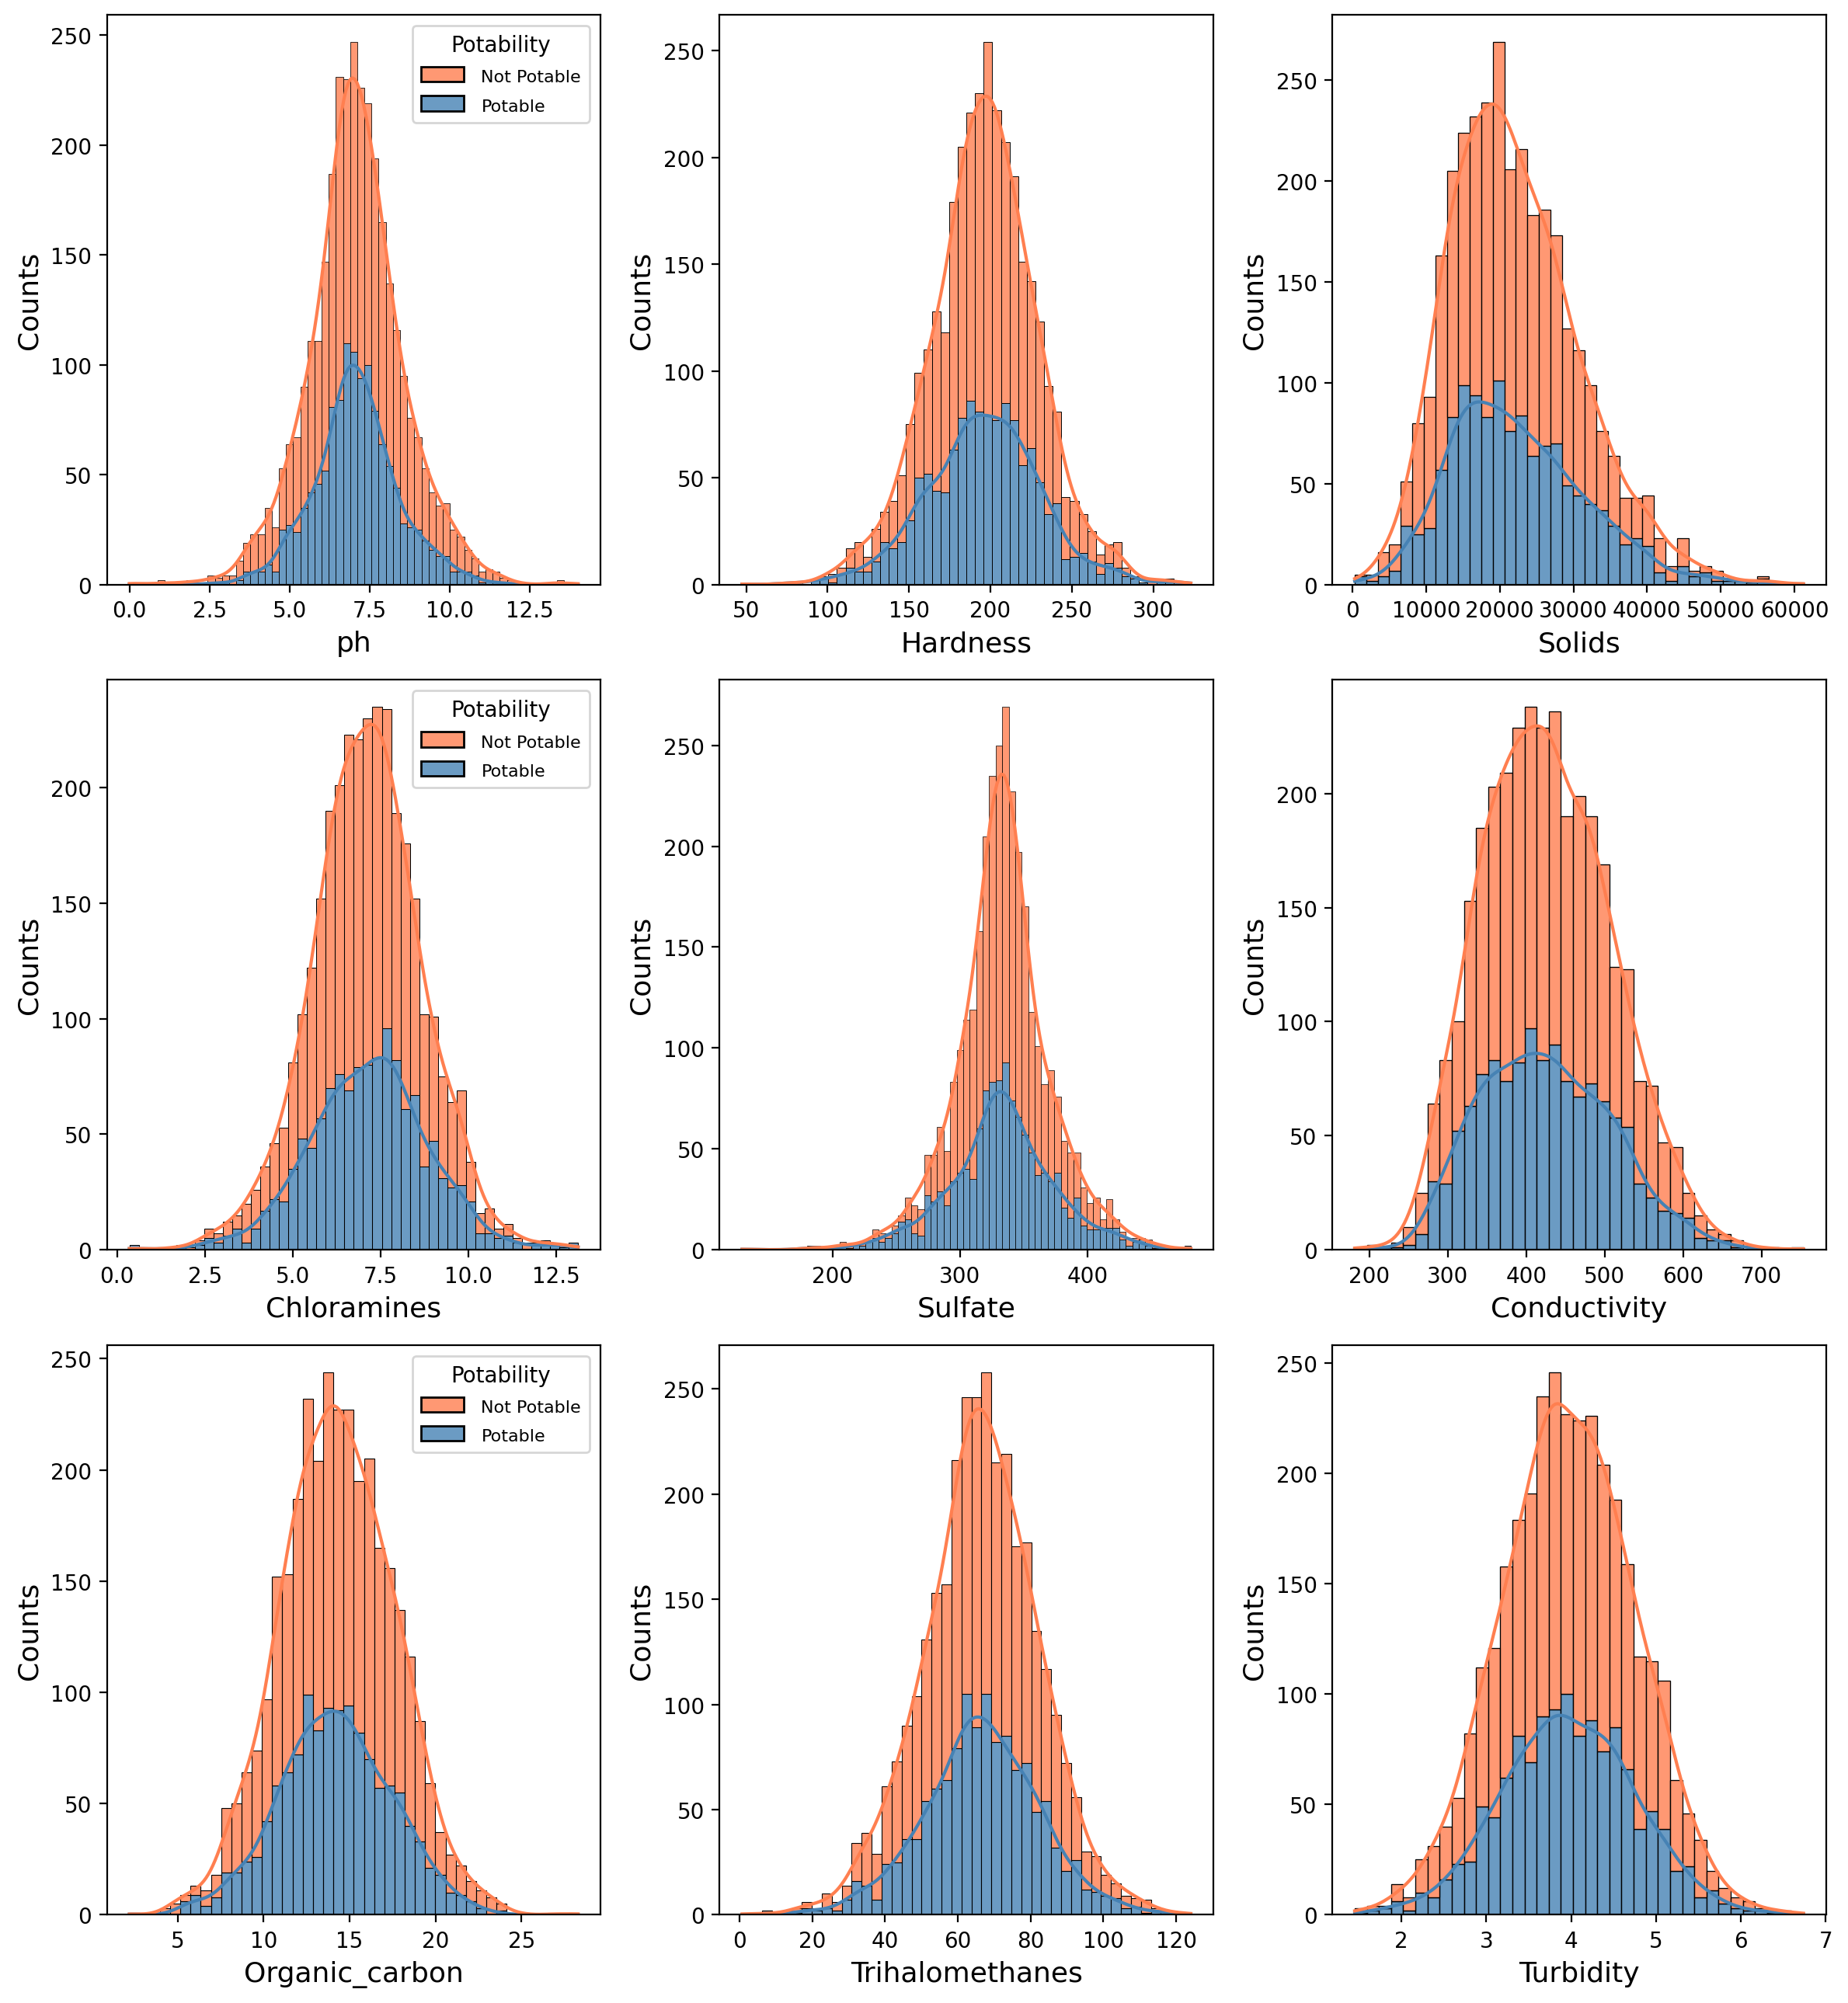

In [22]:
continuous_features= knn_impute_df.select_dtypes(include= np.number).columns

fig, axes= plt.subplots(3,3, figsize= (12,13), dpi= 200)
for i, (ax, feature) in enumerate(zip(axes.flatten(),continuous_features)):
    sns.histplot(data=knn_impute_df, x=feature, hue="Potability", ax= ax, kde= True, multiple="stack", palette={"Not Potable": "coral", "Potable": "steelblue"}, alpha= 0.8)
    ax.set_ylabel("Counts",fontsize= 13)
    ax.set_xlabel(feature, fontsize= 13)

    if i% 3 !=0:
        ax.get_legend().remove()
    else:
        ax.legend_.get_title().set_fontsize('10')
        plt.setp(ax.legend_.get_texts(), fontsize='8')

plt.tight_layout()
plt.show()
    

### Figure 4: Boxplot of continous features

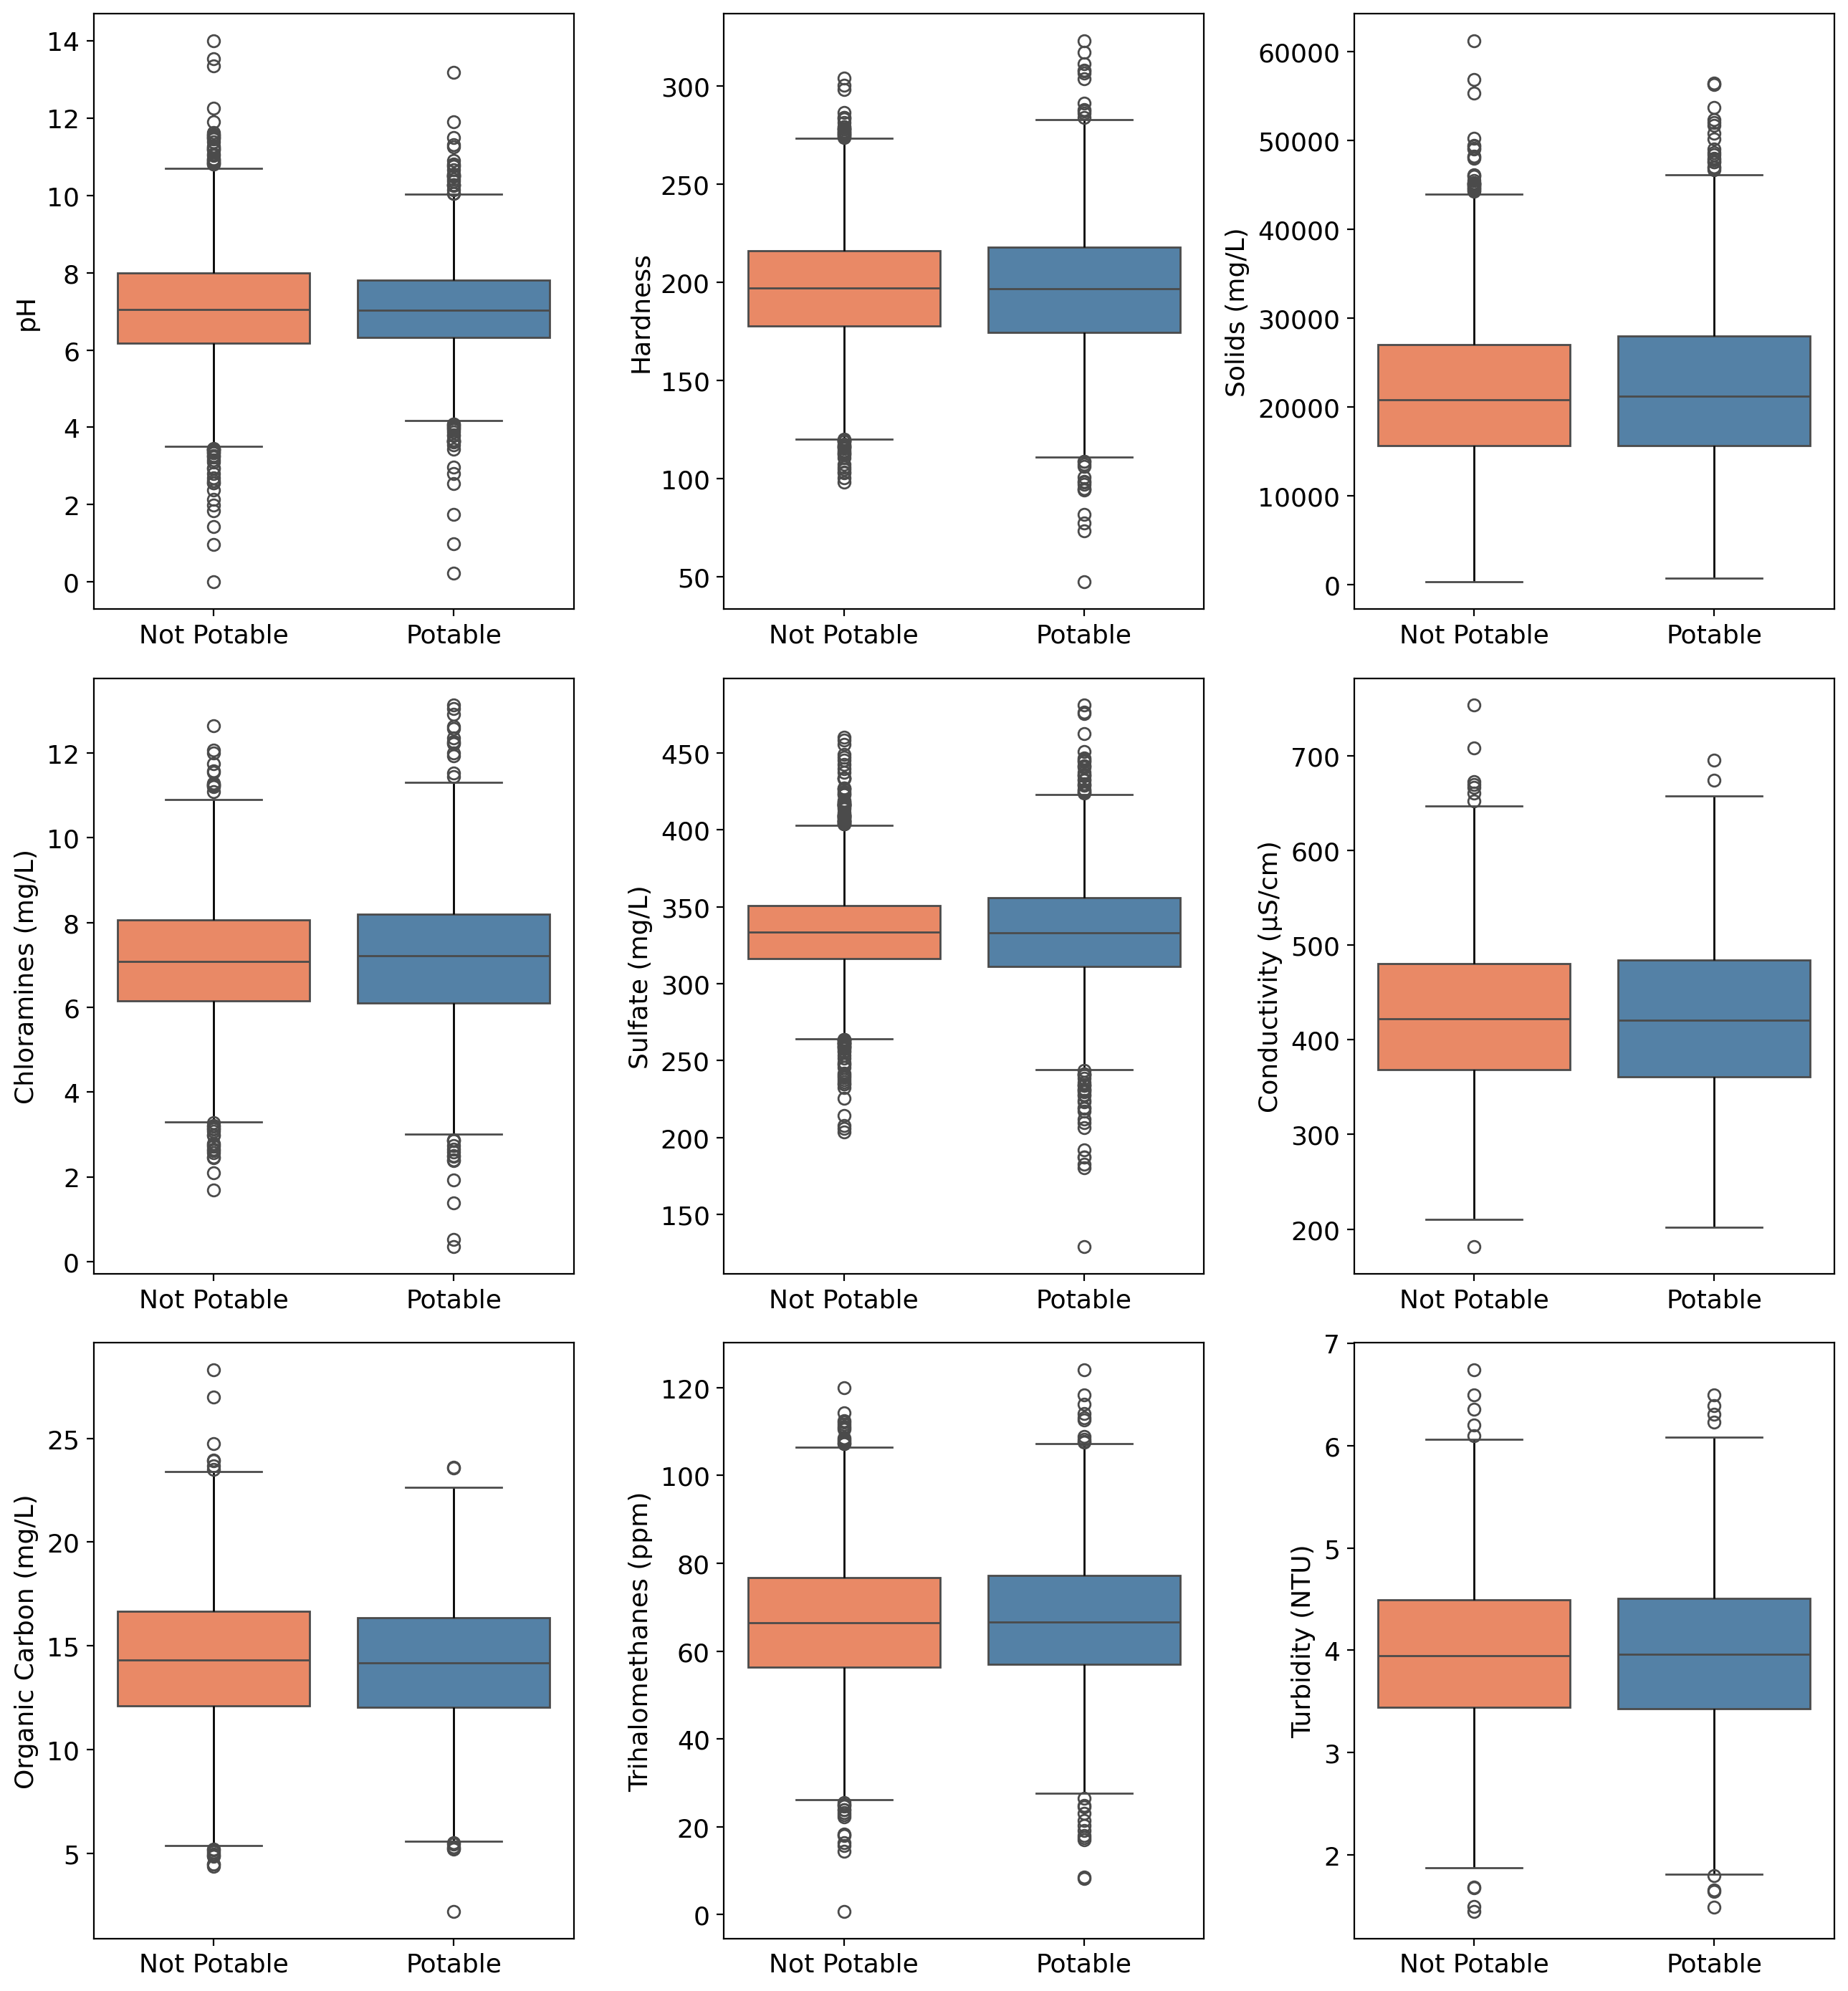

In [23]:
fig, axes= plt.subplots(3,3, figsize= (13,14), dpi= 200)
axes_flat= axes.flatten()
y_labels= ["pH","Hardness","Solids (mg/L)","Chloramines (mg/L)","Sulfate (mg/L)","Conductivity (µS/cm)","Organic Carbon (mg/L)","Trihalomethanes (ppm)","Turbidity (NTU)"]

for i, (feature, ax) in enumerate(zip(continuous_features, axes_flat)):
    sns.boxplot(data=knn_impute_df, x="Potability", y=feature, ax= ax, hue= "Potability", legend= False, palette={"Not Potable": "coral", "Potable": "steelblue"},whiskerprops={"color": "black"})
    ax.set_ylabel(y_labels[i], fontsize= 13)
    ax.set(xlabel=None)
    ax.tick_params("both", labelsize= 13)

for ax in axes_flat[len(continuous_features):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

### Figure 5: Heatmap of pairwise correlations

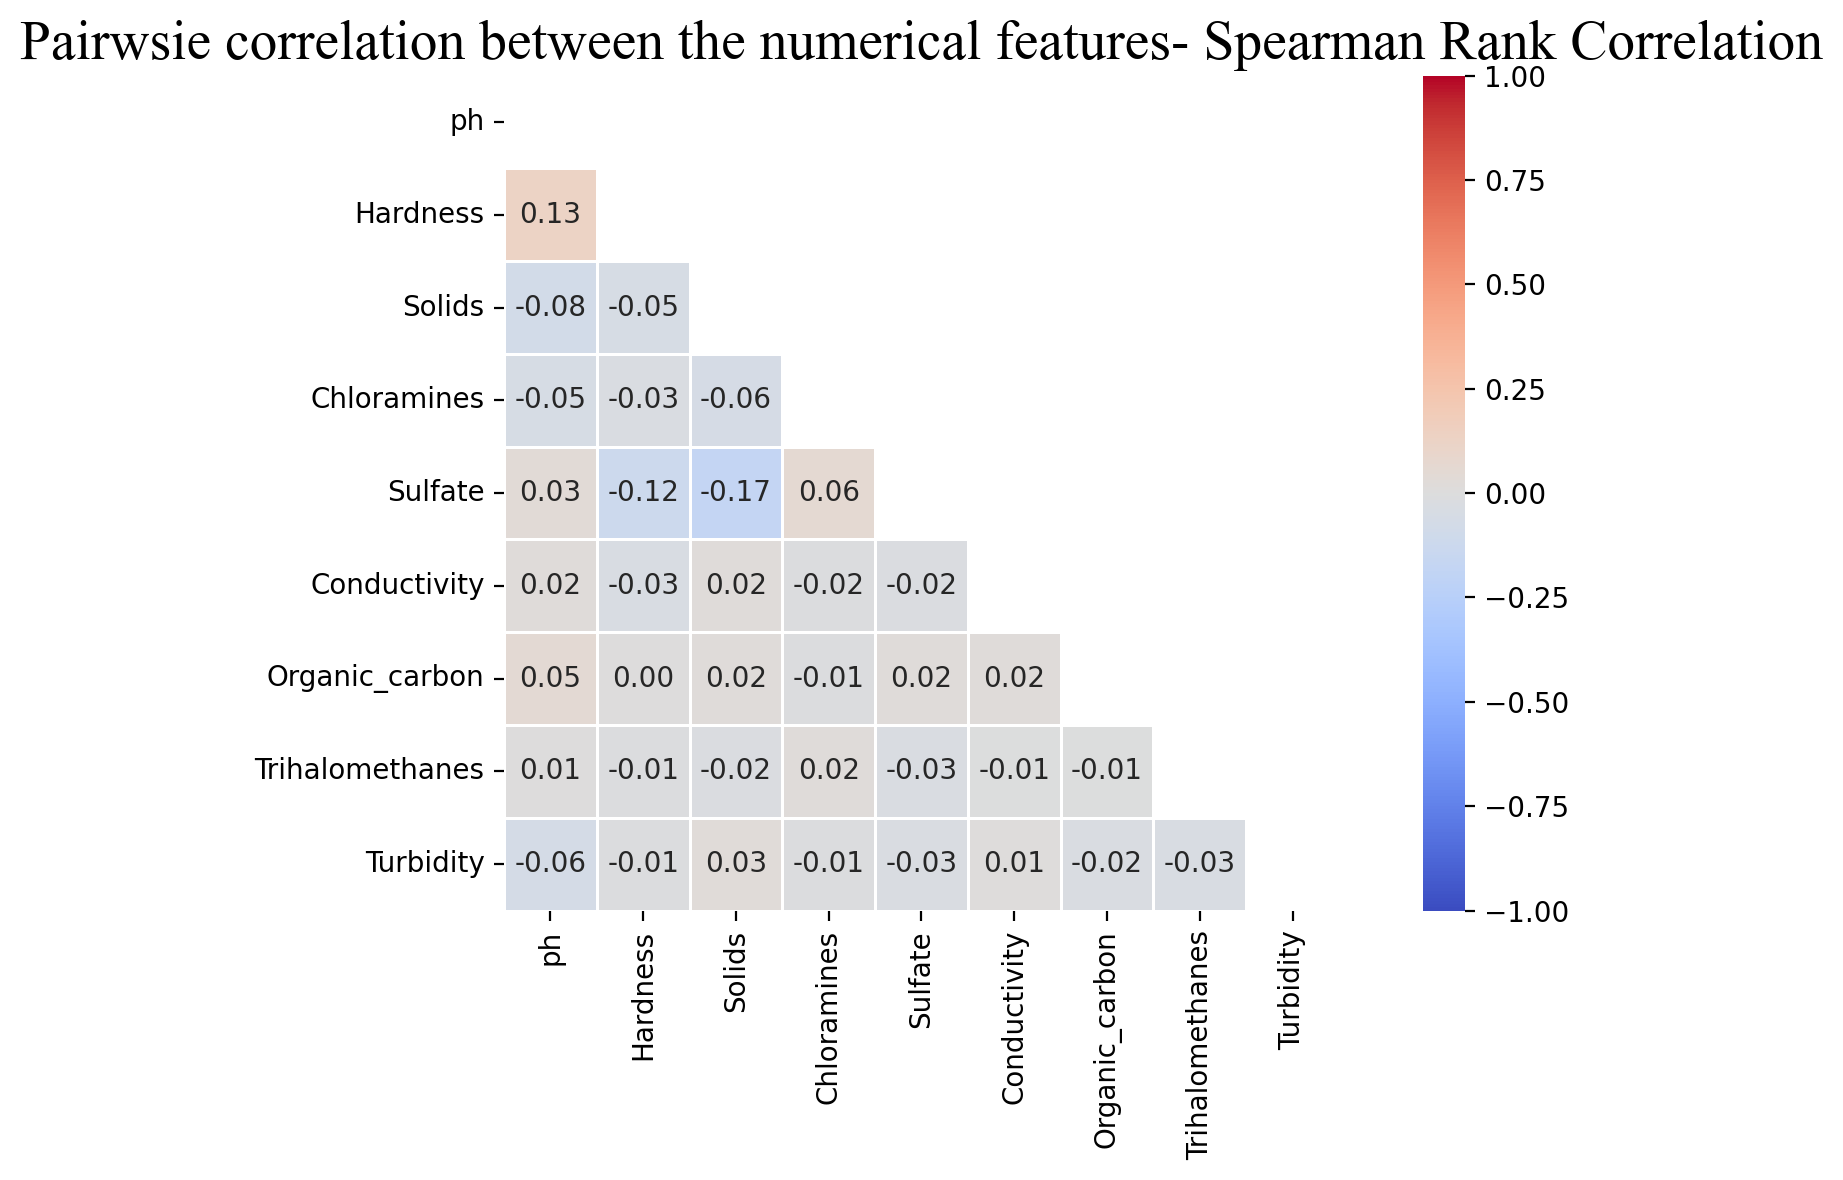

In [24]:
corr = knn_impute_df[continuous_features].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))  # hiding the redundant upper triangle just for better visualization
plt.figure(figsize=(9,6), dpi= 200)
sns.heatmap(corr, mask= mask, cmap= "coolwarm", vmin= -1, vmax= 1, annot= True, fmt= ".2f", linewidth= 1, square= True)
plt.title("Pairwsie correlation between the numerical features- Spearman Rank Correlation", fontdict=font_dic)
plt.tight_layout()
plt.show()

### Figure 6: Scatter plots of all features against pH to examine relationships and potential patterns

In [25]:
def scatter_plot(data, x_variable= "ph", y_variable= "Hardness", hue_variable= "Potability", safe_x_min= 6.5, safe_x_max= 8.5, safe_y_min= None, safe_y_max= None, y_unit= None):
    """
    Plots a scatter plot between two variables
    safe_x_min: Lower limit of the reference range for the x-variable.
    safe_x_max: Upper limit of the reference range for the x-variable.
    safe_y_min: Lower limit of the reference range for the y-variable.
    safe_y_max: Upper limit of the reference range for the y-variable.
    """
    sns.set_theme(style="whitegrid", color_codes=True)
    fig , ax = plt.subplots(figsize=(9,7), dpi=200)
    Hue_Order= ["Potable", "Not Potable"] 
    sns.scatterplot(data= data, x=x_variable, y=y_variable, hue=hue_variable, palette= {"Not Potable": "coral", "Potable": "steelblue"}, hue_order= Hue_Order, linewidth=0.5, edgecolor= "black", ax=ax,
                    alpha= 0.9, s= 30)
    ax.set_title(f"{x_variable} versus {y_variable} Scatter plot", fontdict=font_dic)
    ax.set_xlabel(x_variable, fontdict=font_dic)

    if y_unit is not None:
        ax.set_ylabel(f"{y_variable} ({y_unit})", fontdict=font_dic)
    else:
        ax.set_ylabel(y_variable, fontdict=font_dic)

    ax.tick_params(axis="both", labelsize= 14, colors='black')
    # Applying a small margin for the y axes
    y_min= data[y_variable].min()
    y_max= data[y_variable].max()
    y_margin= (y_max-y_min)*0.1

    ax.set_ylim(0, y_max+ y_margin)

    # Highlight the reference range for the x-variable 
    if (safe_x_min is not None) and (safe_x_max is not None):
        ax.axvspan(safe_x_min, safe_x_max, facecolor="lightgreen", alpha=0.7, label= f"Safe {x_variable} Range",zorder=0)
        ax.axvline(x= safe_x_min, linestyle= "--", color= "lightgreen", linewidth= 2)
        ax.axvline(x= safe_x_max, linestyle= "--", color= "lightgreen", linewidth= 2)

    # Highlight the reference range for the y-variable
    if (safe_y_min is not None) and (safe_y_max is not None):
        ax.axhspan(safe_y_min,safe_y_max, facecolor= "sandybrown", alpha= 0.2, label=f"Safe {y_variable} Range",zorder=0)
        ax.axhline(y= safe_y_min, linestyle= ":", color= "sandybrown", linewidth= 2)
        ax.axhline(y= safe_y_max,linestyle= ":", color= "sandybrown", linewidth= 2)

    plt.legend()
    plt.show()

In [26]:
scatter_settings = {
    "Hardness": {
        "safe_y_min": None,
        "safe_y_max": None,
        "unit": None
    },

    "Solids": {
        "safe_y_min": 0,
        "safe_y_max": 500,
        "unit": "mg/L"
    },

    "Chloramines": {
        "safe_y_min": 0,
        "safe_y_max": 4,
        "unit": "mg/L"
    },

    "Sulfate": {
        "safe_y_min": 3,
        "safe_y_max": 30,
        "unit": "mg/L"
    },

    "Conductivity": {
        "safe_y_min": 0,
        "safe_y_max": 400,
        "unit": "µS/cm"
    },

    "Organic_carbon": {
        "safe_y_min": 0,
        "safe_y_max": 4,
        "unit": "mg/L"
    },

    "Trihalomethanes": {
        "safe_y_min": 0,
        "safe_y_max": 80,
        "unit": "ppm"
    },

    "Turbidity": {
        "safe_y_min": 0,
        "safe_y_max": 1,
        "unit": "NTU"
    }
}

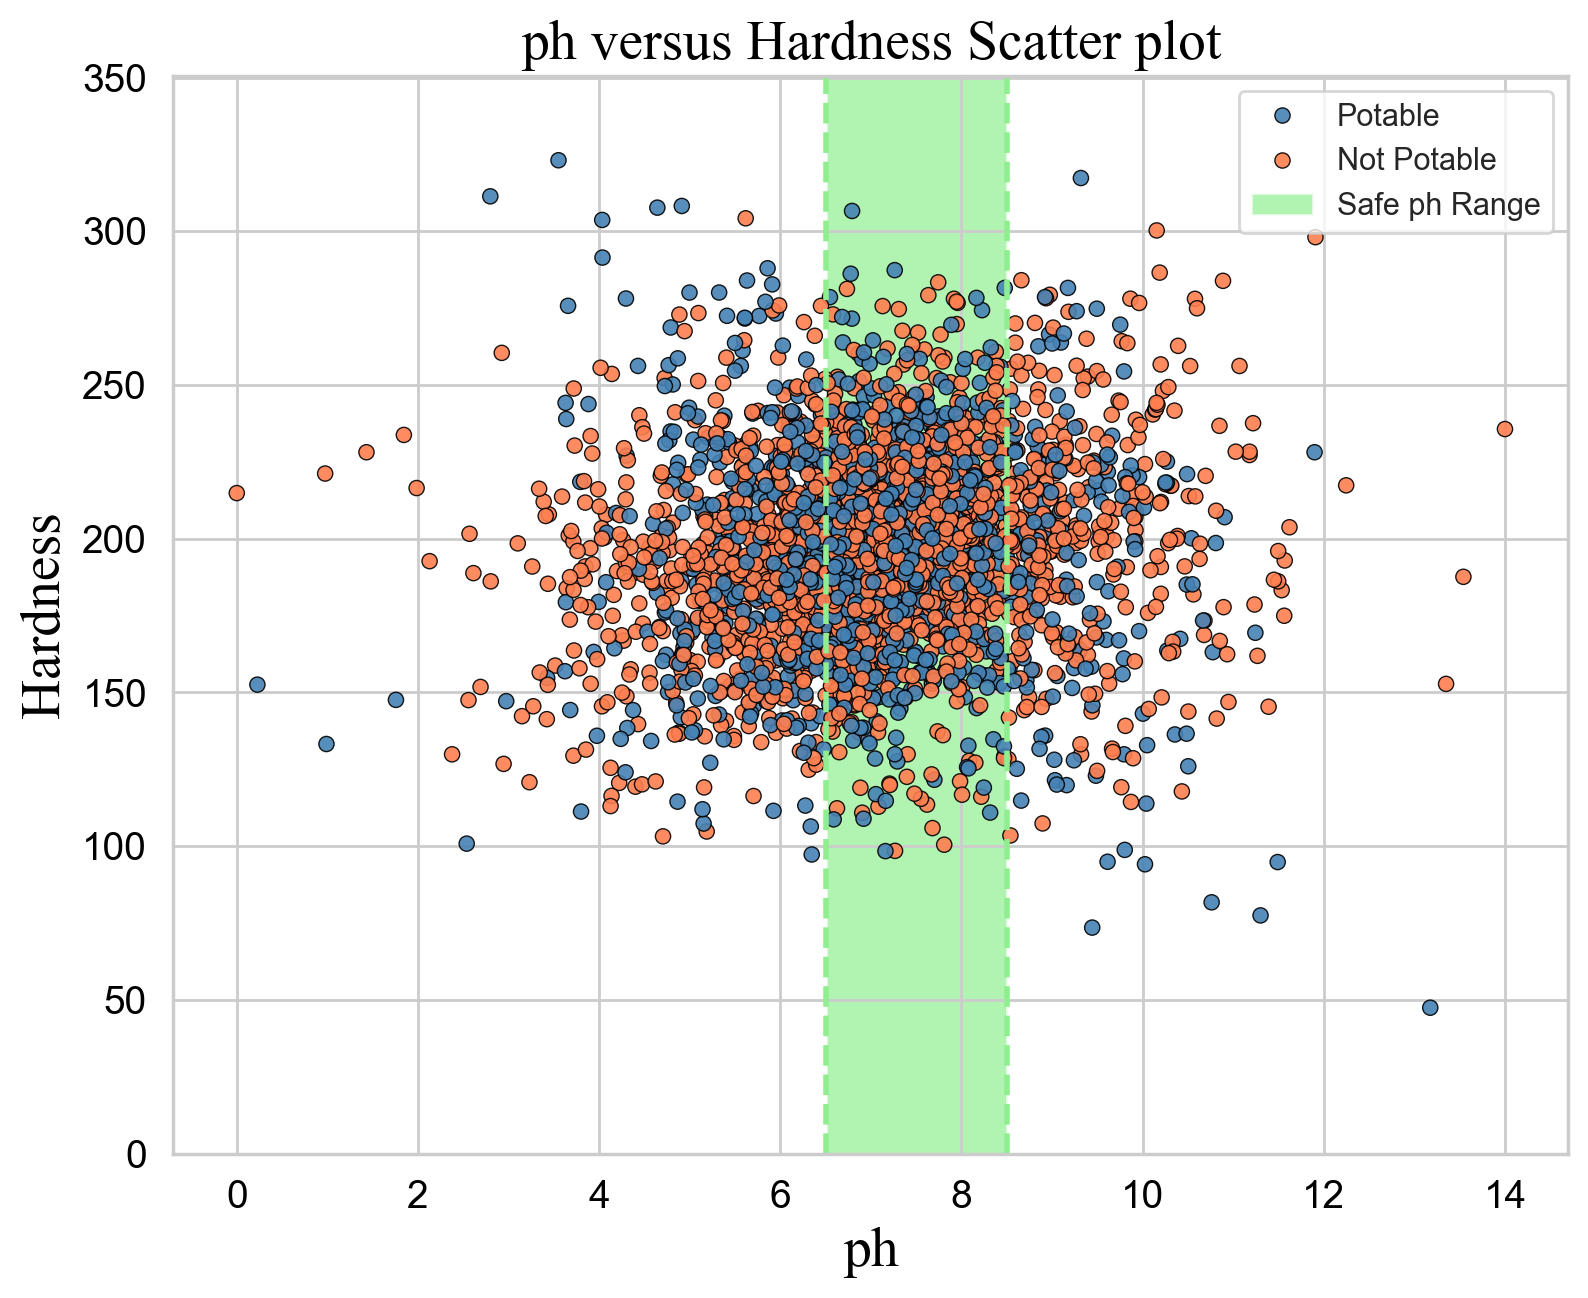

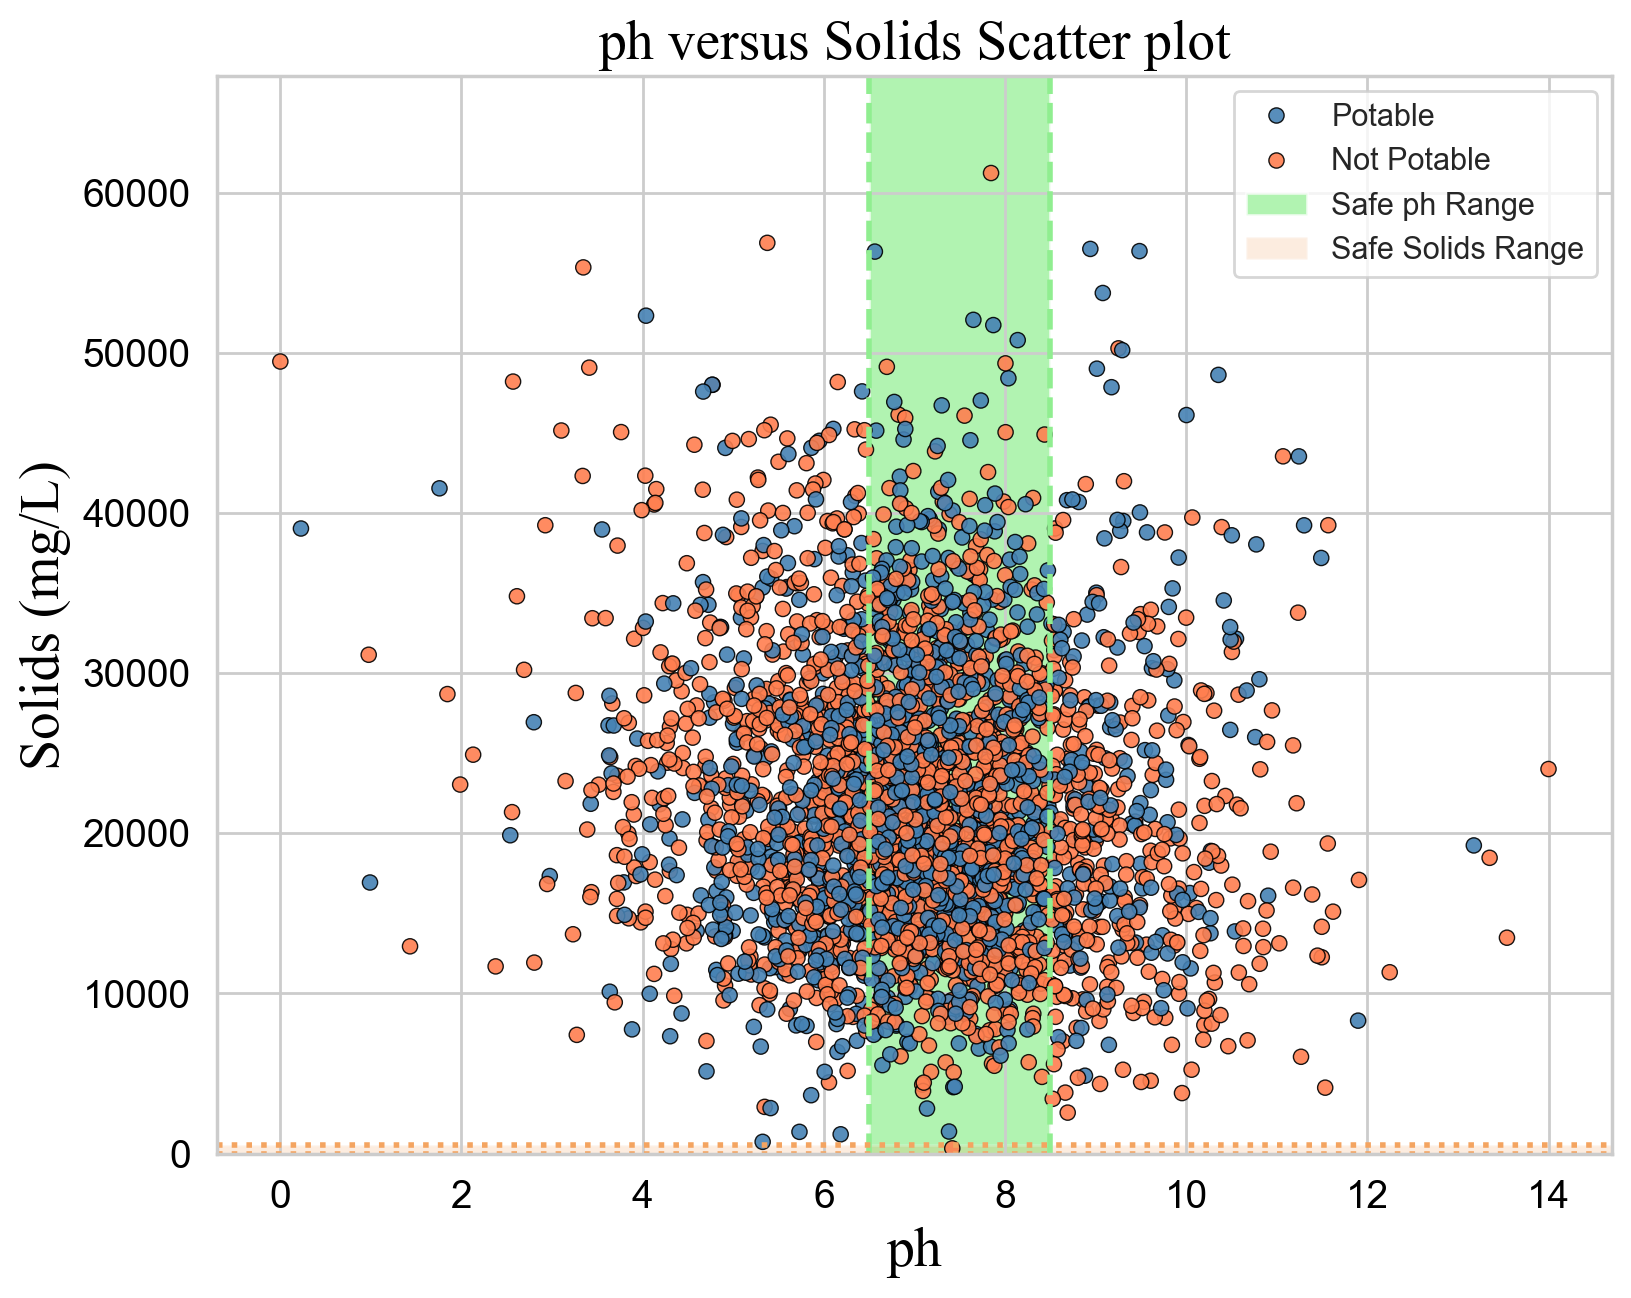

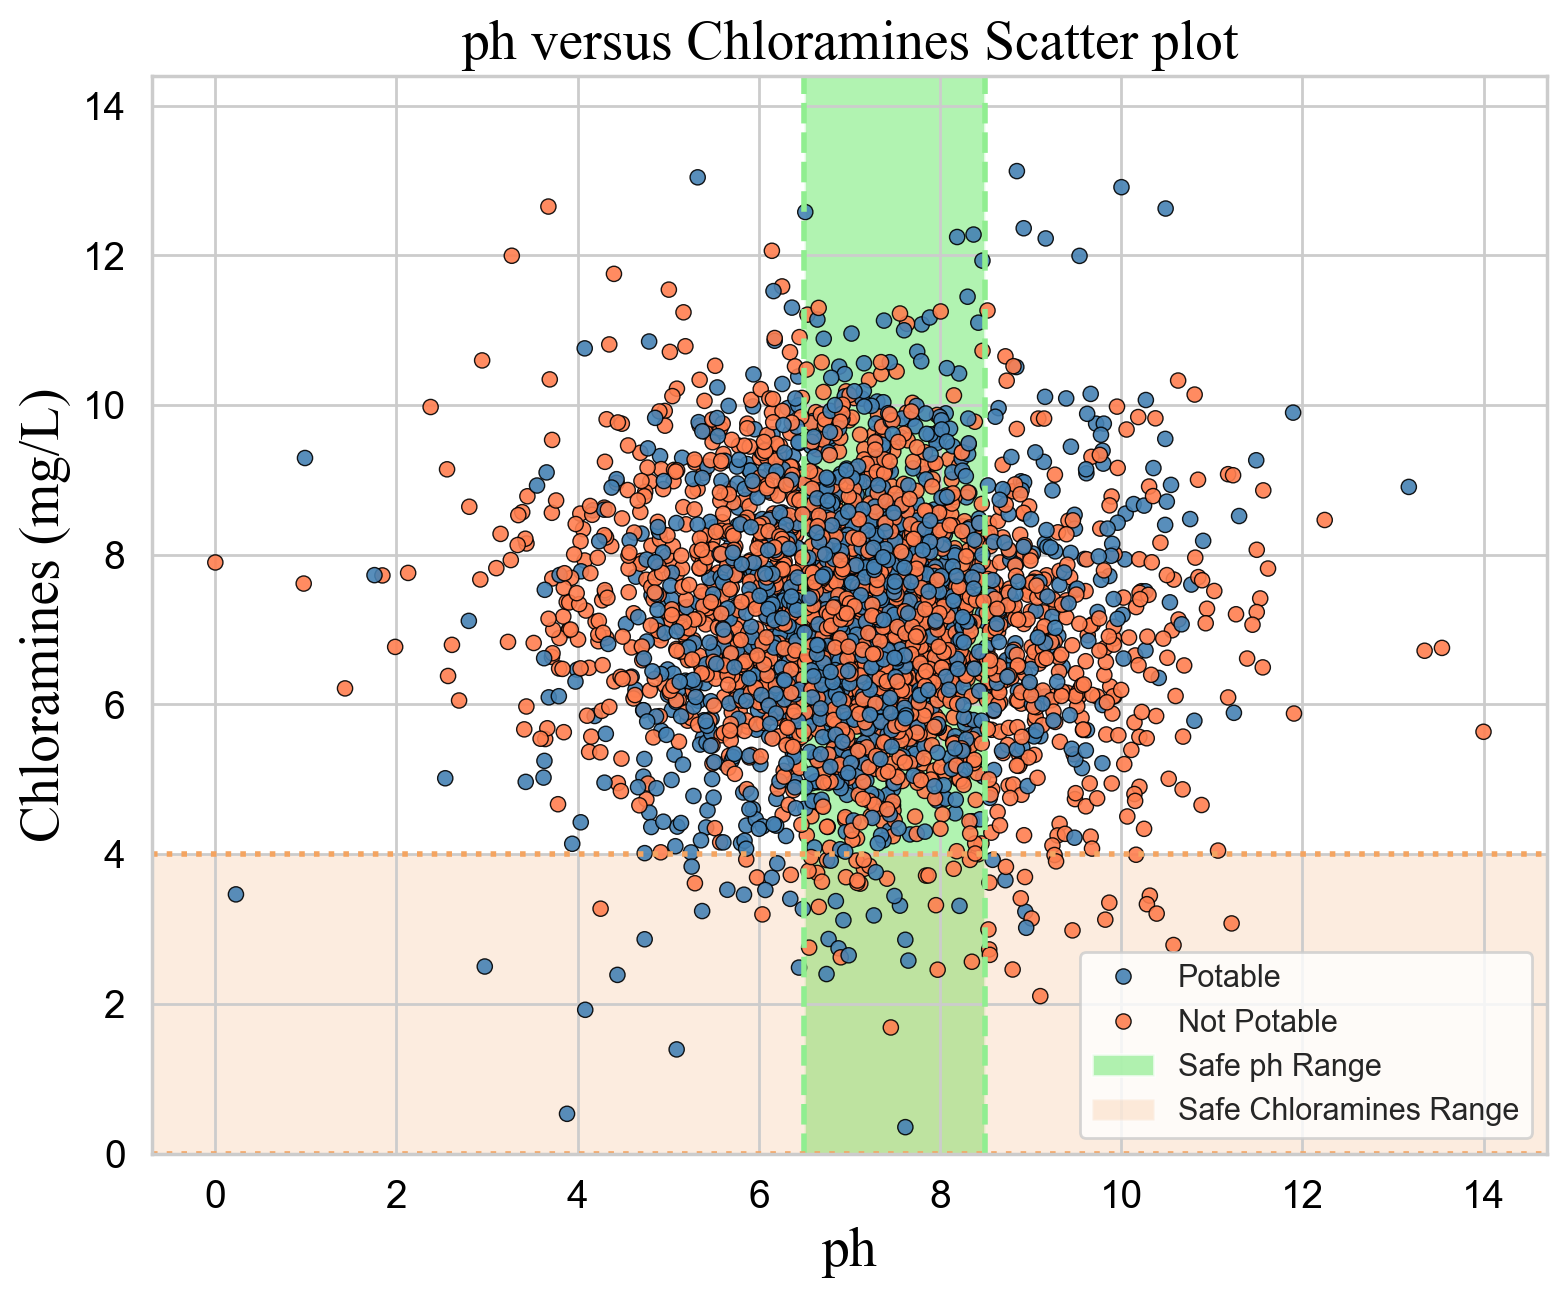

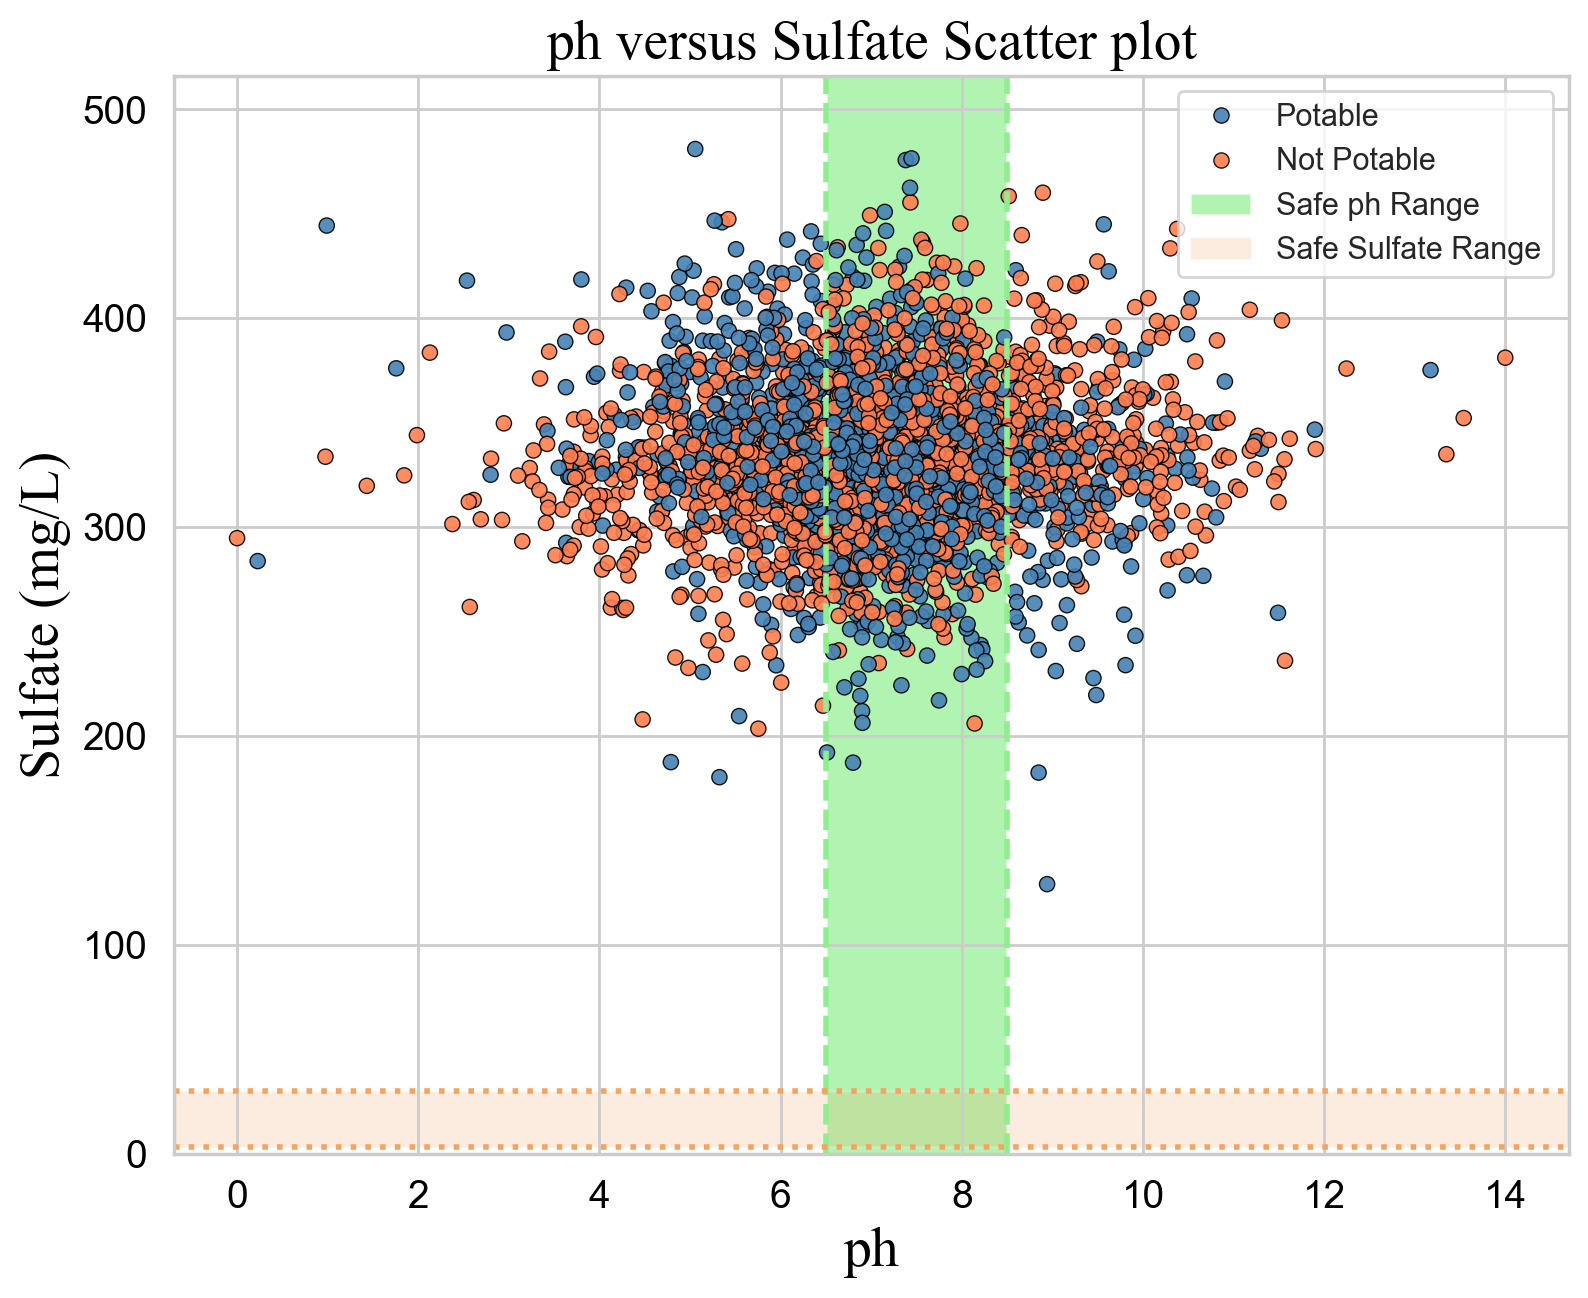

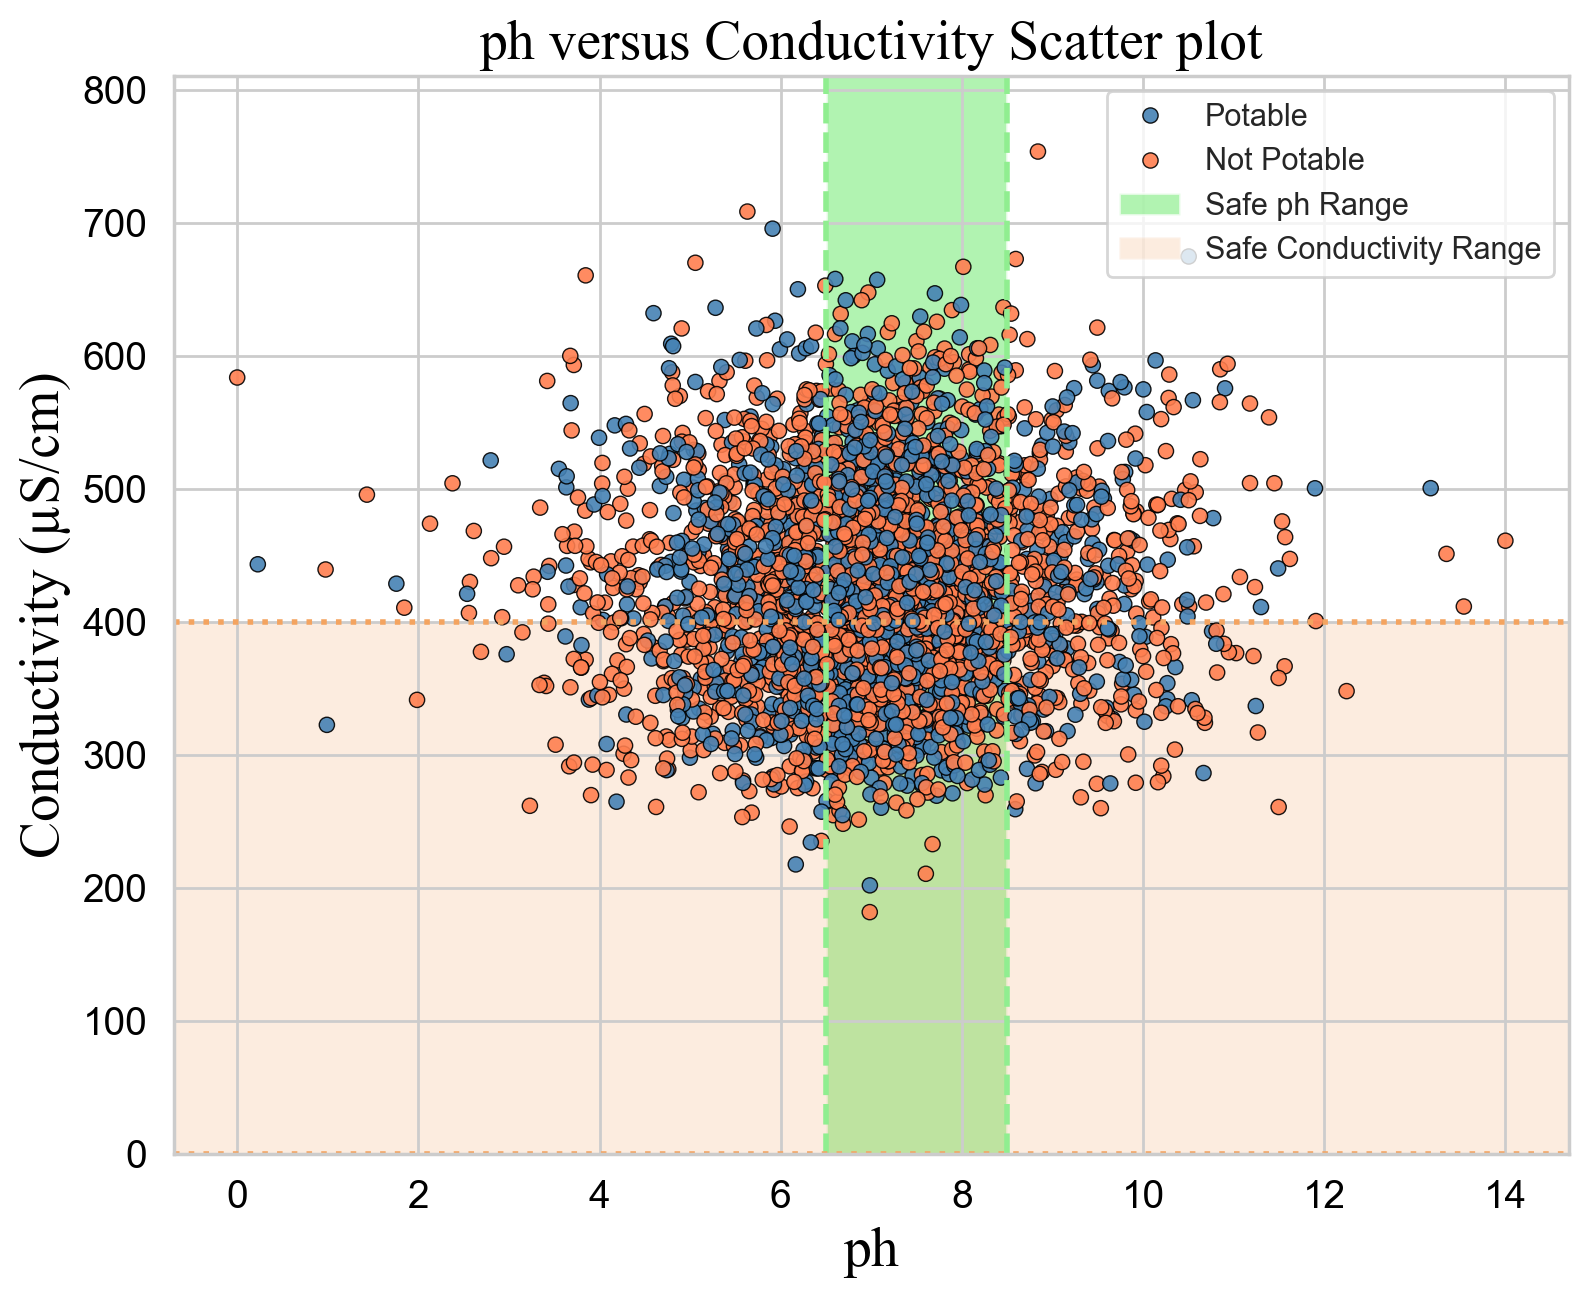

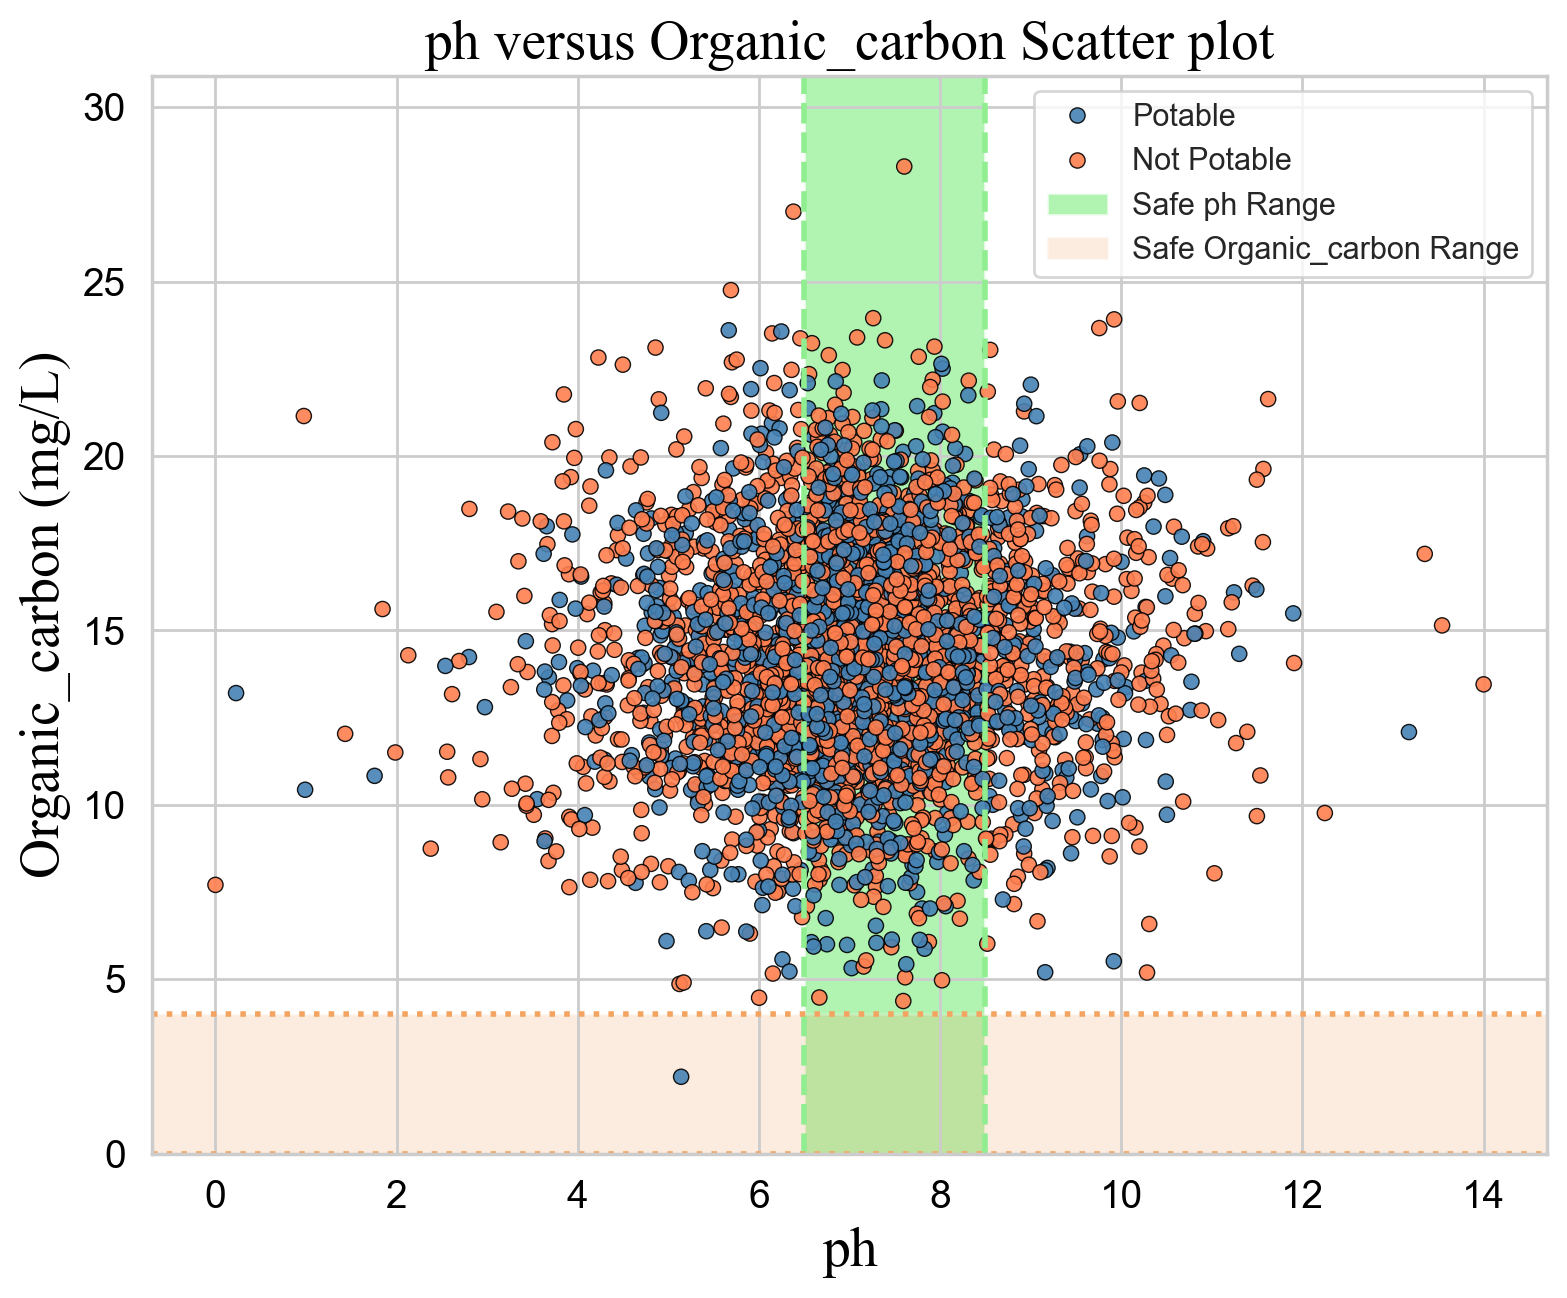

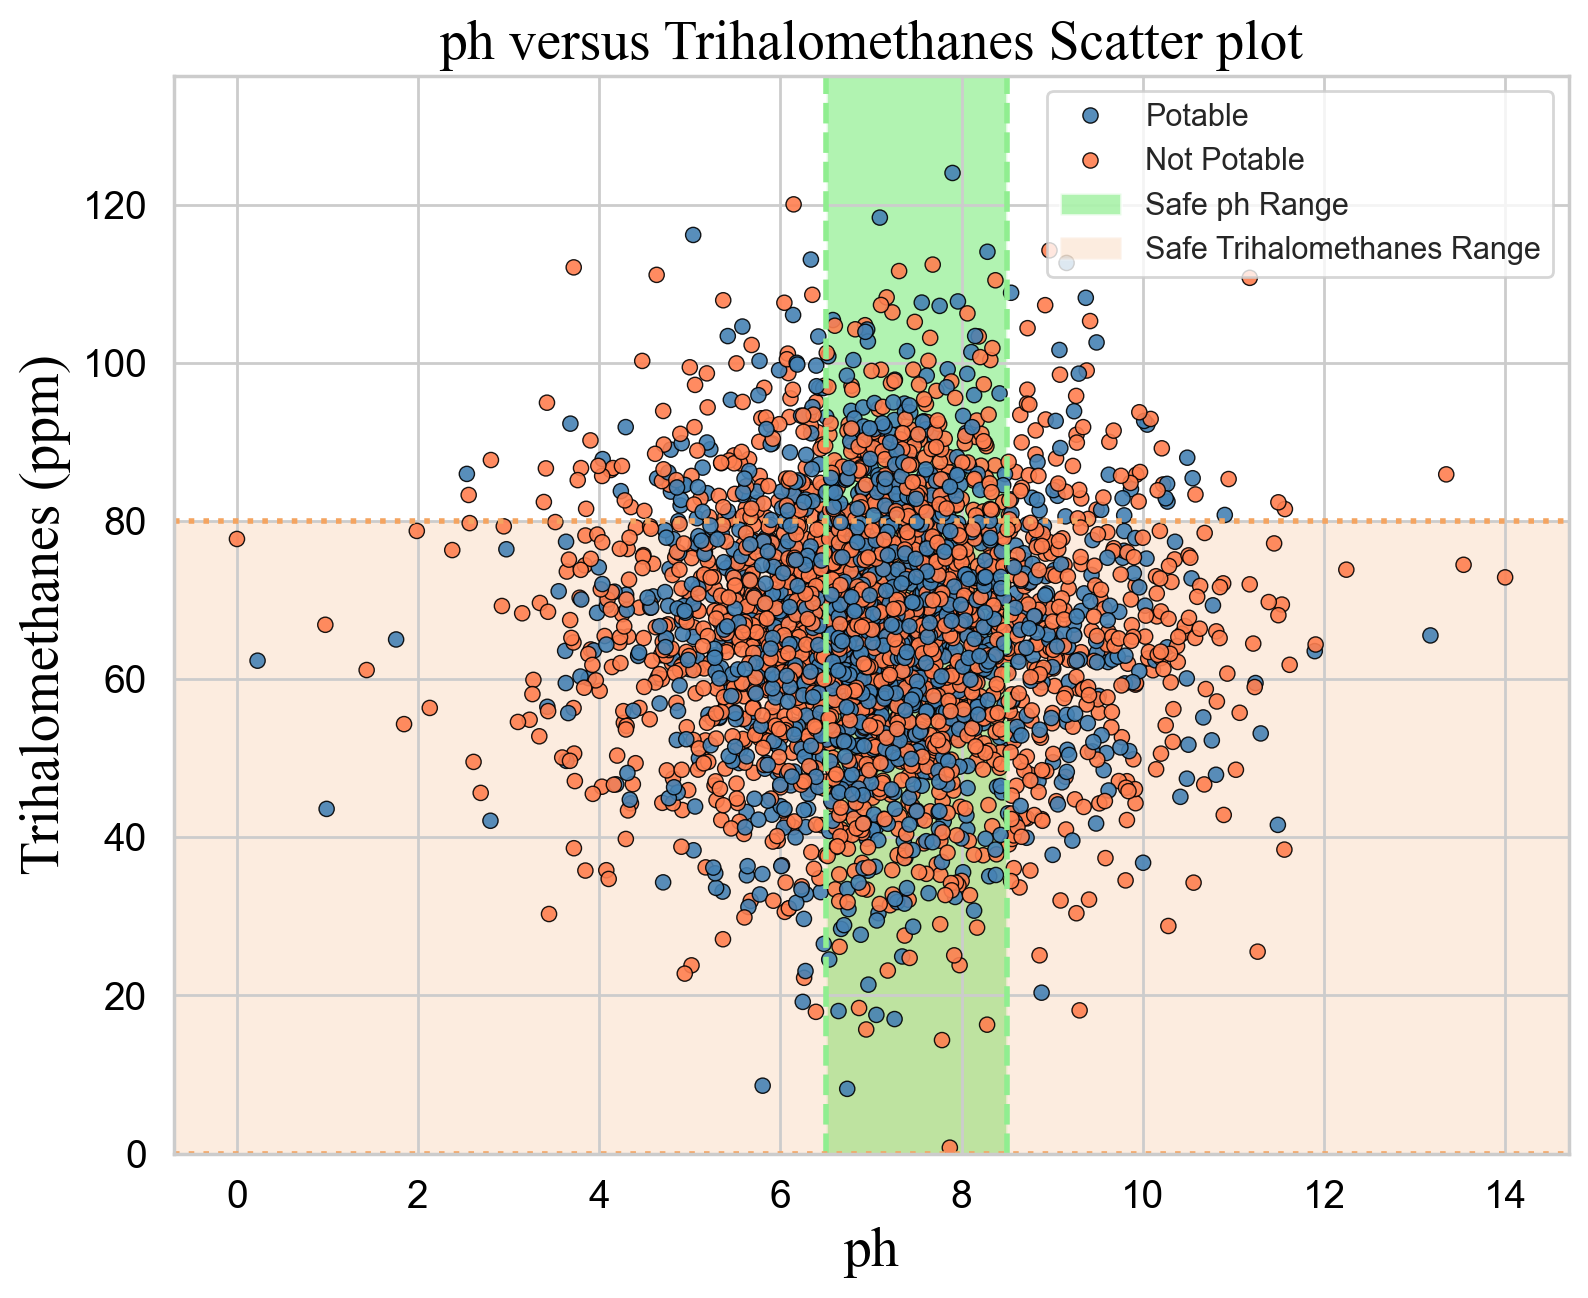

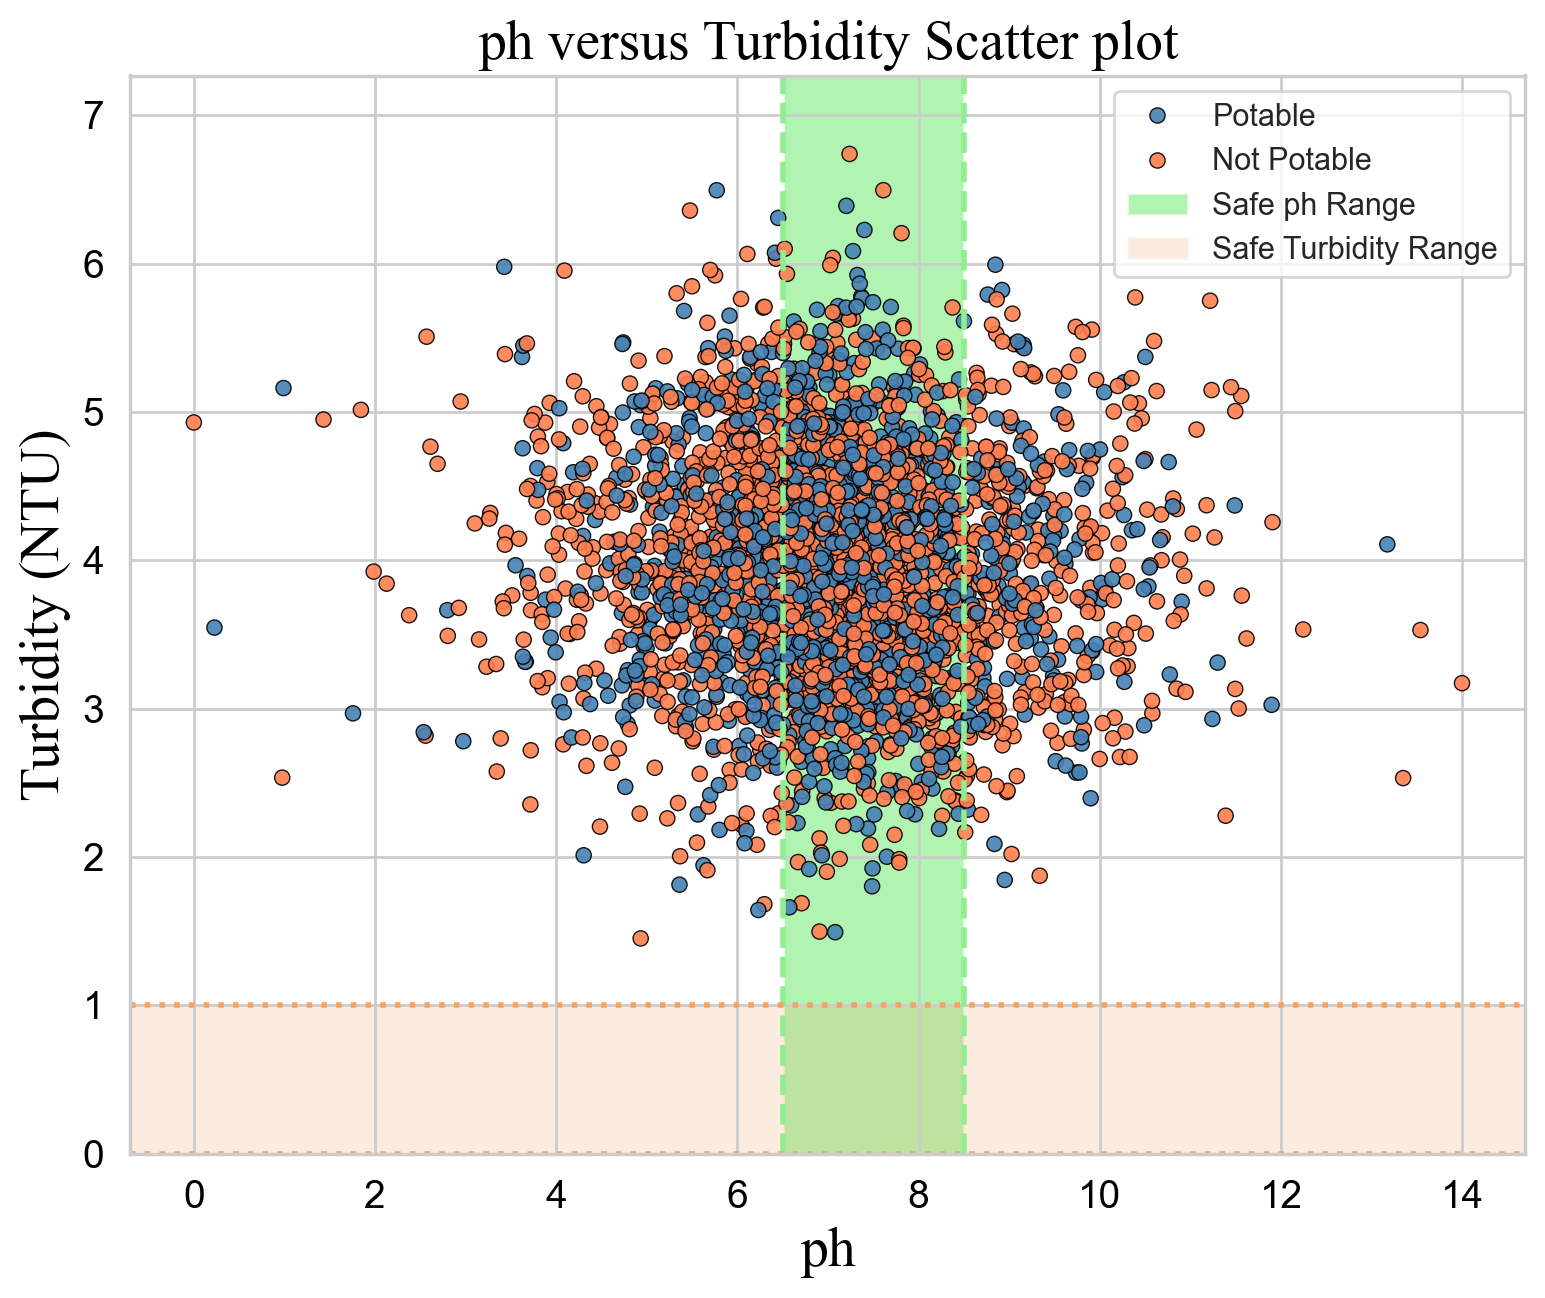

In [27]:
for y_variable, settings in scatter_settings.items():
    scatter_plot( data=knn_impute_df, y_variable=y_variable, safe_y_min=settings["safe_y_min"], safe_y_max=settings["safe_y_max"], y_unit=settings["unit"])

### Key Findings

- Missing values were limited to **pH, Sulfate, and Trihalomethanes**. Sulfate had the highest proportion of missing values, followed by pH and Trihalomethanes.
- Only **9 observations** were missing all three features simultaneously, representing approximately **0.27%** of the original dataset.
- Missingness occurred in both potability groups. The stacked-bar plots show missing observations among both potable and non-potable samples for pH, Sulfate, and Trihalomethanes.
- The feature distributions of potable and non-potable water **overlap substantially**. Across the histograms and KDE curves, the two classes show similar distribution shapes for most variables.
- The boxplots identify observations beyond the whiskers for most of variables, indicating observations that are unusually distant from the central distribution according to the IQR range.
- Pairwise relationships among the numerical features are generally weak. The Spearman correlation coefficients are approximately between −0.17 and 0.13, with most values close to zero. The **largest negative association** is between **Solids and Sulfate** (\(\rho \approx -0.17\)), while the **largest positive association** is between **pH and Hardness** (\(\rho \approx 0.13\)).
- The scatter plots similarly show no strong relationship between pH and the other water-quality variables.
- Several observations fall outside the safe ranges highlighted in the scatter plots. This occurs for both potable and non-potable samples, and some samples labelled as Potable have measurements outside the highlighted reference ranges for pH or the corresponding y-axis feature.